# Modélisation multi-approches

## 1. Contexte et stratégie

L'objectif est de prédire la CHARGE (= FREQ × CM x ANNEE_ASSURANCE) pour chaque contrat du test en minimisant le RMSE. On déploie 15+ modèles organisés en 4 blocs :

- **Bloc A (Décomposé actuariel)** : FREQ × CM x ANNEE_ASSURANCE avec séparation attritionnels/graves et TVE
- **Bloc B (Direct)** : Tweedie, Poisson, Hurdle — prédiction directe de la CHARGE
- **Bloc C (AutoML)** : AutoGluon en 1, 2 et 3 stages avec stacking
- **Bloc D (Ensemble)** : multi-seed averaging, stacking niveau 2, ensemble final

Chaque modèle produit des prédictions out-of-fold (OOF) sur le train et des prédictions sur le test. Les OOF servent à :
1. Évaluer chaque modèle sans biais (RMSE OOF)
2. Alimenter le stacking de niveau 2
3. Optimiser les poids de l'ensemble final

## 2. Imports et chargement

### 2.1. Setup

In [0]:
%pip install autogluon.tabular lightgbm xgboost optuna
dbutils.library.restartPython()

Note: you may need to restart the kernel using dbutils.library.restartPython() to use updated packages.
Looking in indexes: https://afa-nrepo-python.azure-paas.intraxa/repository/pypi-group/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 22.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 47.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 7.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 29.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 29.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 9.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 24.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 22.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 19.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 48.6 MB/s eta 0:00:00


In [0]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genpareto, norm
from scipy.optimize import minimize

from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, roc_auc_score
from sklearn.linear_model import PoissonRegressor, GammaRegressor, TweedieRegressor
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMClassifier, LGBMRegressor
import lightgbm as lgb
import xgboost as xgb
import optuna

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Constantes
SEUIL_GRAVE = 76336
PLAFOND = 500000
N_FOLDS = 5
SEEDS = [42, 123, 456, 789, 2024]

### 2.2. Chargement et préparation des cibles

In [0]:
train = pd.read_csv("new_data/train_advanced_fe.csv")
test = pd.read_csv("new_data/test_advanced_fe.csv")

target_cols = ['FREQ', 'CM', 'CHARGE', 'IS_PLAFONNE']
feature_cols = [c for c in train.columns if c not in ['ID'] + target_cols]

# --- Cibles dérivées ---
train['HAS_SINISTRE'] = (train['CHARGE'] > 0).astype(int)
train['IS_GRAVE'] = (train['CM'] > SEUIL_GRAVE).astype(int)
train['CM_ATTRIT'] = np.where(
    (train['CM'] > 0) & (train['CM'] <= SEUIL_GRAVE), train['CM'], np.nan
)
train['CM_GRAVE'] = np.where(
    train['CM'] > SEUIL_GRAVE, train['CM'], np.nan
)

# Exposition (pour l'offset Poisson)
train['LOG_EXPO'] = np.log(train['ANNEE_ASSURANCE'].clip(lower=0.01))
test['LOG_EXPO'] = np.log(test['ANNEE_ASSURANCE'].clip(lower=0.01))

print(f"Train : {train.shape}")
print(f"Test  : {test.shape}")
print(f"Features : {len(feature_cols)}")

print(f"\n{'='*55}")
print(f"  STRUCTURE DES CIBLES")
print(f"{'='*55}")
print(f"  Contrats totaux       : {len(train):,}")
print(f"  Sinistrés (CHARGE>0)  : {train['HAS_SINISTRE'].sum():,} ({train['HAS_SINISTRE'].mean()*100:.2f}%)")
print(f"  Attritionnels         : {train['CM_ATTRIT'].notna().sum():,} ({train['CM_ATTRIT'].notna().sum()/max(train['HAS_SINISTRE'].sum(),1)*100:.1f}% des sinistrés)")
print(f"  Graves                : {train['CM_GRAVE'].notna().sum():,} ({train['CM_GRAVE'].notna().sum()/max(train['HAS_SINISTRE'].sum(),1)*100:.1f}% des sinistrés)")
print(f"  Plafonnés             : {train['IS_PLAFONNE'].sum()}")
print(f"\n  CM attrit moyen       : {train['CM_ATTRIT'].mean():,.0f}€")
print(f"  CM grave moyen        : {train['CM_GRAVE'].mean():,.0f}€")
print(f"  CHARGE moyenne        : {train['CHARGE'].mean():,.2f}€")
print(f"  CHARGE totale         : {train['CHARGE'].sum():,.0f}€")

Train : (383610, 278)
Test  : (95852, 270)
Features : 268

  STRUCTURE DES CIBLES
  Contrats totaux       : 383,610
  Sinistrés (CHARGE>0)  : 2,352 (0.61%)
  Attritionnels         : 2,107 (89.6% des sinistrés)
  Graves                : 245 (10.4% des sinistrés)
  Plafonnés             : 20

  CM attrit moyen       : 6,661€
  CM grave moyen        : 228,560€
  CHARGE moyenne        : 186.12€
  CHARGE totale         : 71,398,723€


### 2.3. Infrastructure OOF (Out-of-Fold)

Tous les modèles utiliseront la même infrastructure : prédictions OOF sur le train (pour évaluation et stacking) et prédictions moyennées sur le test. On centralise ça dans une classe utilitaire.

In [0]:
class OOFPredictor:
    """Infrastructure commune pour tous les modèles."""
    
    def __init__(self, n_folds=N_FOLDS):
        self.n_folds = n_folds
        self.results = {}  # stocke OOF + test preds pour chaque modèle
    
    def add_result(self, name, oof_preds, test_preds, metric_name='RMSE'):
        """Enregistre les résultats d'un modèle."""
        rmse = np.sqrt(mean_squared_error(train['CHARGE'], oof_preds))
        mae = mean_absolute_error(train['CHARGE'], oof_preds)
        
        self.results[name] = {
            'oof': oof_preds,
            'test': test_preds,
            'rmse': rmse,
            'mae': mae
        }
        print(f"  ✅ {name:40s} | RMSE = {rmse:>10,.2f}  MAE = {mae:>10,.2f}")
    
    def leaderboard(self):
        """Affiche le classement des modèles."""
        rows = []
        for name, res in self.results.items():
            rows.append({'Modèle': name, 'RMSE': res['rmse'], 'MAE': res['mae']})
        lb = pd.DataFrame(rows).sort_values('RMSE')
        return lb
    
    def get_oof_matrix(self):
        """Retourne la matrice OOF pour le stacking."""
        return pd.DataFrame({name: res['oof'] for name, res in self.results.items()})
    
    def get_test_matrix(self):
        """Retourne la matrice test pour le stacking."""
        return pd.DataFrame({name: res['test'] for name, res in self.results.items()})

oof = OOFPredictor()
print("Infrastructure OOF initialisée")

Infrastructure OOF initialisée


## 3. Bloc A — Modèles décomposés (actuariels)

### 3.1. A1 — Fréquence : LightGBM Classifier

On prédit P(sinistre) = P(CHARGE > 0). C'est le premier étage de la décomposition. On utilise un StratifiedKFold pour garantir que chaque fold a le même ratio de sinistrés (~0.61%).

In [0]:
X = train[feature_cols].values
y_freq = train['HAS_SINISTRE'].values
X_test = test[feature_cols].values

oof_freq = np.zeros(len(train))
test_freq = np.zeros(len(test))

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y_freq)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y_freq[train_idx], y_freq[val_idx]
    
    model = LGBMClassifier(
        n_estimators=1000,
        max_depth=6,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.6,
        min_child_samples=50,
        reg_alpha=0.1,
        reg_lambda=1.0,
        scale_pos_weight=len(y_tr[y_tr==0]) / max(len(y_tr[y_tr==1]), 1),
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    oof_freq[val_idx] = model.predict_proba(X_val)[:, 1]
    test_freq += model.predict_proba(X_test)[:, 1] / N_FOLDS

auc_freq = roc_auc_score(y_freq, oof_freq)
print(f"A1 — Fréquence LightGBM :")
print(f"  AUC OOF        : {auc_freq:.4f}")
print(f"  P(sin) moyenne  : {oof_freq.mean():.4f} (réel : {y_freq.mean():.4f})")
print(f"  P(sin) test     : {test_freq.mean():.4f}")

# Feature importance
fi = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(f"\n  Top 15 features :")
for feat, imp in fi.head(15).items():
    print(f"    {feat:40s} : {imp}")

A1 — Fréquence LightGBM :
  AUC OOF        : 0.7501
  P(sin) moyenne  : 0.2364 (réel : 0.0061)
  P(sin) test     : 0.2374

  Top 15 features :
    ANNEE_ASSURANCE                          : 4
    PCA_RANK_1                               : 2
    ZONE                                     : 2
    SURFACE_PER_NBBAT                        : 2
    PCA_TExTE_10                             : 2
    EQUIP_PER_KAPITAL                        : 1
    KAPITAL_MAX_OVER_MEAN                    : 1
    KAPITAL23                                : 1
    BIN_TE_KAPITAL_PER_SURFACE_CM            : 1
    TE_AN_EXERC_CM                           : 1
    ZONE_VENT                                : 1
    INTER_TAILLE1_x_KAPITAL_TOTAL            : 1
    PROPORTION_22                            : 1
    INTER_VOCATION_x_SURFACE_TOTAL           : 1
    INTER_VOCATION_x_KAPITAL_TOTAL           : 1


L'AUC de 0.75 est un bond significatif par rapport au benchmark (0.58). Le modèle discrimine bien les sinistrés des non-sinistrés. En revanche, les probabilités sont mal calibrées : la moyenne prédite (23.6%) est 39x supérieure au taux réel (0.61%). C'est un effet du `scale_pos_weight` qui sur-pondère les sinistrés pour améliorer le ranking, au détriment de la calibration.

On recalibre les probabilités pour que la moyenne prédite corresponde au taux réel. C'est essentiel pour la reconstitution de la charge (FREQ × CM).

### 3.2. Calibration des probabilités

In [0]:
# Calibration simple : scaling
cal_factor = y_freq.mean() / oof_freq.mean()
oof_freq_cal = oof_freq * cal_factor
test_freq_cal = test_freq * cal_factor

print(f"Calibration :")
print(f"  Facteur          : {cal_factor:.6f}")
print(f"  P(sin) OOF avant : {oof_freq.mean():.6f}")
print(f"  P(sin) OOF après : {oof_freq_cal.mean():.6f} (réel : {y_freq.mean():.6f})")
print(f"  P(sin) test après: {test_freq_cal.mean():.6f}")

# Vérification par décile
print(f"\nCalibration par décile :")
train['_pred_cal'] = oof_freq_cal
train['_decile'] = pd.qcut(oof_freq_cal, q=10, labels=False, duplicates='drop')

cal_check = train.groupby('_decile').agg(
    n=('HAS_SINISTRE', 'count'),
    taux_reel=('HAS_SINISTRE', 'mean'),
    taux_pred=('_pred_cal', 'mean')
).reset_index()

cal_check['Ratio'] = cal_check['taux_pred'] / cal_check['taux_reel'].replace(0, np.nan)

print(f"{'Décile':>8} {'n':>8} {'Taux réel':>12} {'Taux prédit':>12} {'Ratio':>8}")
print("-" * 52)
for _, row in cal_check.iterrows():
    print(f"{int(row['_decile']):>8} {int(row['n']):>8} {row['taux_reel']:>12.4%} {row['taux_pred']:>12.4%} {row['Ratio']:>8.2f}")

train.drop(columns=['_pred_cal', '_decile'], inplace=True)

Calibration :
  Facteur          : 0.025935
  P(sin) OOF avant : 0.236411
  P(sin) OOF après : 0.006131 (réel : 0.006131)
  P(sin) test après: 0.006157

Calibration par décile :
  Décile        n    Taux réel  Taux prédit    Ratio
----------------------------------------------------
       0    38804      0.1495%      0.0260%     0.17
       1    40821      0.1519%      0.0342%     0.22
       2    38471      0.1300%      0.0444%     0.34
       3    42090      0.2281%      0.0707%     0.31
       4    33339      0.2010%      0.1207%     0.60
       5    38730      0.4932%      0.4152%     0.84
       6    44266      0.6709%      0.8358%     1.25
       7    36215      0.7290%      1.0677%     1.46
       8    38677      1.5591%      1.7309%     1.11
       9    32197      2.0623%      2.0311%     0.98


La calibration par scaling est imparfaite mais fonctionnelle :
- **Déciles hauts (7-9)** : bien calibrés (ratio 0.98-1.46). Le modèle identifie correctement les contrats les plus risqués.
- **Déciles bas (0-4)** : le modèle sous-estime le risque (ratio 0.17-0.60). Mais ces contrats ont un taux réel de 0.13-0.23% — la différence en valeur absolue est infime.
- **Décile 9** (top 8% des contrats) : taux réel = 2.06%, taux prédit = 2.03% — quasi-parfait. C'est ce décile qui porte l'essentiel de la charge.

La calibration n'a pas besoin d'être parfaite sur les déciles bas : un contrat à 0.03% vs 0.15% de probabilité contribue de toute façon quasi-rien à la charge. Ce qui compte, c'est la calibration sur les déciles hauts — et elle est bonne.

### 3.3. A2 — Sévérité attritionnels : LightGBM Gamma

On modélise E[CM | sinistre attritionnnel] sur les 2 107 sinistres avec CM ∈ (0, 76 336€]. On utilise une loss Gamma (adaptée aux coûts positifs asymétriques) avec un retour en log (Duan smearing) pour corriger le biais de retransformation.

In [0]:
# Données attritionnels uniquement
mask_attrit = train['CM_ATTRIT'].notna()
X_attrit = train.loc[mask_attrit, feature_cols].values
y_attrit = train.loc[mask_attrit, 'CM_ATTRIT'].values
idx_attrit = train.loc[mask_attrit].index

print(f"Attritionnels : {len(y_attrit):,} observations")
print(f"  CM moyen  : {y_attrit.mean():,.0f}€")
print(f"  CM médian : {np.median(y_attrit):,.0f}€")
print(f"  CM max    : {y_attrit.max():,.0f}€")

# Modèle en log(CM) pour stabiliser
y_attrit_log = np.log(y_attrit)

oof_attrit = np.zeros(len(train))
oof_attrit[:] = np.nan
test_attrit = np.zeros(len(test))

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
duan_factors = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_attrit)):
    X_tr, X_val = X_attrit[train_idx], X_attrit[val_idx]
    y_tr, y_val = y_attrit_log[train_idx], y_attrit_log[val_idx]
    
    model = LGBMRegressor(
        n_estimators=1000,
        max_depth=5,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.6,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    # Prédictions en log
    pred_log_val = model.predict(X_val)
    pred_log_test = model.predict(X_test)
    
    # Duan smearing : E[CM] = exp(pred_log) × mean(exp(résidus))
    residuals = y_tr - model.predict(X_tr)
    duan_factor = np.mean(np.exp(residuals))
    duan_factors.append(duan_factor)
    
    # Retransformation avec Duan
    global_idx = idx_attrit[val_idx]
    oof_attrit[global_idx] = np.exp(pred_log_val) * duan_factor
    test_attrit += np.exp(pred_log_test) * duan_factor / N_FOLDS

# Stats
pred_attrit_valid = oof_attrit[~np.isnan(oof_attrit)]
print(f"\nA2 — Sévérité attritionnels :")
print(f"  Duan factor moyen : {np.mean(duan_factors):.4f}")
print(f"  CM prédit moyen   : {pred_attrit_valid.mean():,.0f}€ (réel : {y_attrit.mean():,.0f}€)")
print(f"  CM prédit médian  : {np.median(pred_attrit_valid):,.0f}€ (réel : {np.median(y_attrit):,.0f}€)")
print(f"  RMSE (log)        : {np.sqrt(mean_squared_error(y_attrit_log, np.log(pred_attrit_valid))):,.4f}")
print(f"  RMSE (€)          : {np.sqrt(mean_squared_error(y_attrit, pred_attrit_valid)):,.0f}€")
print(f"  CM test moyen     : {test_attrit.mean():,.0f}€")

Attritionnels : 2,107 observations
  CM moyen  : 6,661€
  CM médian : 1,288€
  CM max    : 76,304€

A2 — Sévérité attritionnels :
  Duan factor moyen : 2.9661
  CM prédit moyen   : 5,047€ (réel : 6,661€)
  CM prédit médian  : 4,826€ (réel : 1,288€)
  RMSE (log)        : 2.0069
  RMSE (€)          : 13,261€
  CM test moyen     : 6,268€


Le modèle de sévérité attritionnel a du mal — ce qui est attendu avec seulement 2 107 observations très dispersées (CM de 1€ à 76k€, skewness élevé) :

- **CM moyen prédit (5 047€) vs réel (6 661€)** : sous-estimation de 24%. Le modèle compresse les prédictions vers le centre.
- **CM médian prédit (4 826€) vs réel (1 288€)** : surestimation de la médiane. Le modèle ne capte pas bien la bimodalité (beaucoup de petits sinistres + quelques gros).
- **Duan factor = 2.97** : élevé, ce qui signifie que les résidus en log sont très dispersés. Le smearing corrige partiellement le biais de retransformation mais ne peut pas compenser un modèle faible.
- **RMSE en log = 2.01** : l'erreur typique est de exp(2) ≈ 7x — le modèle se trompe en moyenne d'un facteur 7 sur le CM individuel.

C'est un résultat classique en actuariat : la sévérité individuelle est très difficile à prédire. Ce qui compte, c'est que la **moyenne** soit à peu près juste (5 047€ vs 6 661€, écart de 24%) — l'erreur se compensera partiellement en portefeuille.

### 3.4. A3 — Sévérité graves : GPD avec covariables (TVE)

Pour les 245 sinistres graves (CM > 76 336€), on utilise la GPD ajustée dans le notebook TVE. Plutôt qu'un GBM (trop peu de données), on combine :
1. Le modèle GPD global (ξ, σ) estimé dans le notebook TVE
2. Un ajustement du paramètre d'échelle σ en fonction des covariables via un GLM log-linéaire

L'idée : σ(X) = exp(Xβ), ce qui permet de personnaliser la sévérité grave par contrat tout en gardant la structure GPD.

In [0]:
# Données graves
mask_grave = train['CM_GRAVE'].notna()
X_grave = train.loc[mask_grave, feature_cols].values
y_grave = train.loc[mask_grave, 'CM_GRAVE'].values
idx_grave = train.loc[mask_grave].index
excesses = y_grave - SEUIL_GRAVE

print(f"Graves : {len(y_grave):,} observations")
print(f"  CM moyen  : {y_grave.mean():,.0f}€")
print(f"  Excès moyen : {excesses.mean():,.0f}€")
print(f"  Plafonnés : {(y_grave >= PLAFOND * 0.99).sum()}")

# Paramètres GPD du notebook TVE (avec censure)
xi_gpd = 0.0190
sigma_gpd = 163322

# Approche 1 : GPD globale (même E[excès] pour tous les graves)
E_excess_gpd = sigma_gpd / (1 - xi_gpd) if xi_gpd < 1 else np.inf
E_cm_grave_gpd = SEUIL_GRAVE + E_excess_gpd

print(f"\nA3a — GPD globale :")
print(f"  ξ = {xi_gpd:.4f}, σ = {sigma_gpd:,.0f}")
print(f"  E[excès] = {E_excess_gpd:,.0f}€")
print(f"  E[CM grave] = {E_cm_grave_gpd:,.0f}€ (réel : {y_grave.mean():,.0f}€)")

# Approche 2 : LightGBM sur log(excès) pour personnaliser
oof_grave = np.zeros(len(train))
oof_grave[:] = np.nan
test_grave = np.zeros(len(test))

y_excess_log = np.log(np.maximum(excesses, 1))

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_grave)):
    X_tr, X_val = X_grave[train_idx], X_grave[val_idx]
    y_tr, y_val = y_excess_log[train_idx], y_excess_log[val_idx]
    
    model = LGBMRegressor(
        n_estimators=500,
        max_depth=3,          # Peu profond : 245 observations
        learning_rate=0.05,
        num_leaves=8,         # Très contraint
        subsample=0.8,
        colsample_bytree=0.4,
        min_child_samples=10,
        reg_alpha=1.0,        # Forte régularisation
        reg_lambda=5.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    pred_log_val = model.predict(X_val)
    pred_log_test = model.predict(X_test)
    
    # Duan smearing
    residuals = y_tr - model.predict(X_tr)
    duan = np.mean(np.exp(residuals))
    
    global_idx = idx_grave[val_idx]
    oof_grave[global_idx] = SEUIL_GRAVE + np.exp(pred_log_val) * duan
    test_grave += (SEUIL_GRAVE + np.exp(pred_log_test) * duan) / N_FOLDS

pred_grave_valid = oof_grave[~np.isnan(oof_grave)]
print(f"\nA3b — GPD + LightGBM personnalisé :")
print(f"  CM grave prédit moyen : {pred_grave_valid.mean():,.0f}€ (réel : {y_grave.mean():,.0f}€)")
print(f"  CM grave test moyen   : {test_grave.mean():,.0f}€")
print(f"  RMSE (€)              : {np.sqrt(mean_squared_error(y_grave, pred_grave_valid)):,.0f}€")

# On garde la GPD globale comme fallback
test_grave_gpd = np.full(len(test), E_cm_grave_gpd)

Graves : 245 observations
  CM moyen  : 228,560€
  Excès moyen : 152,224€
  Plafonnés : 20

A3a — GPD globale :
  ξ = 0.0190, σ = 163,322
  E[excès] = 166,485€
  E[CM grave] = 242,821€ (réel : 228,560€)

A3b — GPD + LightGBM personnalisé :
  CM grave prédit moyen : 201,741€ (réel : 228,560€)
  CM grave test moyen   : 182,748€
  RMSE (€)              : 124,448€


Deux approches pour les graves :

- **GPD globale** : E[CM grave] = 242 821€ vs réel 228 560€ — surestimation de 6%. Honnête pour un modèle sans covariables. La GPD avec ξ = 0.019 (quasi-Gumbel) donne une espérance raisonnable.

- **LightGBM personnalisé** : E[CM grave] = 201 741€ — sous-estimation de 12%. Avec seulement 245 observations et une forte régularisation, le modèle compresse les prédictions. Le RMSE de 124k€ est élevé mais inévitable sur des sinistres de 76k à 500k€.

La GPD globale est plus fiable en moyenne (écart de 6% vs 12%). Le LightGBM personnalisé pourrait apporter de la variance utile dans l'ensemble final. On conserve les deux.

Pour la reconstitution, on utilisera principalement la GPD globale (plus stable) et le LightGBM comme variante.

### 3.5. A4 — Reconstitution de la CHARGE

On assemble les trois étages :
- P(sinistre) × [P(attrit|sinistre) × E[CM_attrit] + P(grave|sinistre) × E[CM_grave]] × exposition

Avec :
- P(sinistre) = modèle A1 (calibré)
- P(grave|sinistre) = proportion observée (245/2352 = 10.4%)
- E[CM_attrit] = modèle A2 (LightGBM Gamma + Duan)
- E[CM_grave] = modèle A3a (GPD globale) ou A3b (LightGBM)

In [0]:
# Proportions observées
p_grave_given_sin = train['IS_GRAVE'].sum() / max(train['HAS_SINISTRE'].sum(), 1)
p_attrit_given_sin = 1 - p_grave_given_sin

print(f"P(grave | sinistre) = {p_grave_given_sin:.4f}")
print(f"P(attrit | sinistre) = {p_attrit_given_sin:.4f}")

# --- Reconstitution A4a : avec GPD globale ---
charge_oof_a4a = (
    oof_freq_cal * 
    (p_attrit_given_sin * test_attrit.mean() + p_grave_given_sin * E_cm_grave_gpd) *
    train['ANNEE_ASSURANCE'].values
)

charge_test_a4a = (
    test_freq_cal *
    (p_attrit_given_sin * test_attrit.mean() + p_grave_given_sin * E_cm_grave_gpd) *
    test['ANNEE_ASSURANCE'].values
)

oof.add_result('A4a — Décomposé (GPD globale)', charge_oof_a4a, charge_test_a4a)

# --- Reconstitution A4b : avec sévérité personnalisée ---
# Pour l'OOF, on utilise les prédictions individuelles quand disponibles
cm_oof_individuel = np.where(
    ~np.isnan(oof_attrit), oof_attrit,
    np.where(~np.isnan(oof_grave), oof_grave, 0)
)
# Pour les non-sinistrés, on utilise la moyenne pondérée
cm_moyen_portfolio = p_attrit_given_sin * test_attrit.mean() + p_grave_given_sin * test_grave.mean()

charge_oof_a4b = oof_freq_cal * cm_moyen_portfolio * train['ANNEE_ASSURANCE'].values

charge_test_a4b = (
    test_freq_cal *
    (p_attrit_given_sin * test_attrit + p_grave_given_sin * test_grave) *
    test['ANNEE_ASSURANCE'].values
)

oof.add_result('A4b — Décomposé (LightGBM grave)', charge_oof_a4b, charge_test_a4b)

# --- Reconstitution A4c : fréquence × sévérité globale (simple) ---
cm_global = train.loc[train['CM'] > 0, 'CM'].mean()
charge_oof_a4c = oof_freq_cal * cm_global * train['ANNEE_ASSURANCE'].values
charge_test_a4c = test_freq_cal * cm_global * test['ANNEE_ASSURANCE'].values

oof.add_result('A4c — Décomposé (CM global)', charge_oof_a4c, charge_test_a4c)

print(f"\n  CM moyen global (tous sinistrés) : {cm_global:,.0f}€")
print(f"  CM moyen pondéré (attrit+grave)  : {cm_moyen_portfolio:,.0f}€")
print(f"  E[CM grave] GPD                  : {E_cm_grave_gpd:,.0f}€")

# Leaderboard intermédiaire
print(f"\n{'='*60}")
display(oof.leaderboard())

P(grave | sinistre) = 0.1042
P(attrit | sinistre) = 0.8958
  ✅ A4a — Décomposé (GPD globale)            | RMSE =   6,799.11  MAE =     339.92
  ✅ A4b — Décomposé (LightGBM grave)         | RMSE =   6,799.13  MAE =     308.68
  ✅ A4c — Décomposé (CM global)              | RMSE =   6,799.08  MAE =     334.25

  CM moyen global (tous sinistrés) : 29,775€
  CM moyen pondéré (attrit+grave)  : 24,652€
  E[CM grave] GPD                  : 242,821€



Modèle,RMSE,MAE
A4c — Décomposé (CM global),6799.084121567443,334.2512453733376
A4a — Décomposé (GPD globale),6799.1105648937655,339.91581835405566
A4b — Décomposé (LightGBM grave),6799.125793292381,308.68175428307524


Les trois variantes décomposées donnent des RMSE quasi-identiques (~6 799). La sévérité (GPD vs LightGBM vs global) ne fait presque pas de différence une fois multipliée par P(sinistre) ≈ 0.6%. C'est le modèle de fréquence qui porte l'essentiel de la performance.

La MAE est plus discriminante : A4b (sévérité personnalisée) a la meilleure MAE (309€ vs 334-340€), ce qui suggère qu'elle est meilleure sur les contrats sinistrés individuels, même si le RMSE global est similaire.

On passe aux modèles directs qui prédisent la CHARGE sans décomposition — ils pourraient capter des interactions fréquence-sévérité que l'approche décomposée manque.

## 4. Bloc B — Modèles directs

### 4.1. B1 — LightGBM Tweedie

La distribution Tweedie est le choix naturel pour des données de charge : elle gère nativement les zéros (pas de sinistre) et la queue lourde (gros sinistres) dans un seul modèle. Le paramètre de puissance p ∈ (1,2) interpole entre Poisson (p=1) et Gamma (p=2). On optimise p avec Optuna.

In [0]:
# --- Étape 1 : Optimisation des hyperparamètres avec Optuna ---
def objective_tweedie(trial):
    params = {
        'objective': 'tweedie',
        'tweedie_variance_power': trial.suggest_float('tweedie_p', 1.1, 1.9),
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    y_target = train['CHARGE'].values
    rmses = []
    
    skf = KFold(n_splits=3, shuffle=True, random_state=42)  # 3 folds pour la vitesse
    
    for train_idx, val_idx in skf.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y_target[train_idx], y_target[val_idx]
        
        model = LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        
        pred = model.predict(X_val)
        pred = np.maximum(pred, 0)
        rmses.append(np.sqrt(mean_squared_error(y_val, pred)))
    
    return np.mean(rmses)

print("Optimisation Optuna — LightGBM Tweedie (100 trials)...")
study_tweedie = optuna.create_study(direction='minimize')
study_tweedie.optimize(objective_tweedie, n_trials=100, show_progress_bar=True)

best_params_tw = study_tweedie.best_params
print(f"\nMeilleurs hyperparamètres :")
for k, v in best_params_tw.items():
    print(f"  {k:25s} : {v}")
print(f"  RMSE Optuna (3-fold)    : {study_tweedie.best_value:,.2f}")

[I 2026-03-27 09:51:25,237] A new study created in memory with name: no-name-bc5dab70-dc2b-48a8-84eb-12f432ac4ab4


Optimisation Optuna — LightGBM Tweedie (100 trials)...


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-27 09:51:49,025] Trial 0 finished with value: 6796.780640386714 and parameters: {'tweedie_p': 1.3713672567399937, 'n_estimators': 1547, 'max_depth': 6, 'learning_rate': 0.022716783404725546, 'num_leaves': 62, 'subsample': 0.7036859444374596, 'colsample_bytree': 0.7639922890368996, 'min_child_samples': 66, 'reg_alpha': 2.3524272799396115, 'reg_lambda': 2.5722234077413013}. Best is trial 0 with value: 6796.780640386714.
[I 2026-03-27 09:52:20,664] Trial 1 finished with value: 6793.468694852789 and parameters: {'tweedie_p': 1.1146758146195048, 'n_estimators': 2407, 'max_depth': 6, 'learning_rate': 0.014167135474539194, 'num_leaves': 43, 'subsample': 0.7574858500254338, 'colsample_bytree': 0.7407087078653845, 'min_child_samples': 76, 'reg_alpha': 0.24006702865543295, 'reg_lambda': 8.58358311984398}. Best is trial 1 with value: 6793.468694852789.
[I 2026-03-27 09:52:39,982] Trial 2 finished with value: 6796.556700307087 and parameters: {'tweedie_p': 1.6034117576156643, 'n_estimat

### 4.1. Entraînement final B1 — Tweedie avec les meilleurs hyperparamètres

In [0]:
# --- Étape 2 : Entraînement 5-fold avec les meilleurs HP ---
oof_tweedie = np.zeros(len(train))
test_tweedie = np.zeros(len(test))

params_tw_final = {
    'objective': 'tweedie',
    'tweedie_variance_power': best_params_tw['tweedie_p'],
    'n_estimators': best_params_tw['n_estimators'],
    'max_depth': best_params_tw['max_depth'],
    'learning_rate': best_params_tw['learning_rate'],
    'num_leaves': best_params_tw['num_leaves'],
    'subsample': best_params_tw['subsample'],
    'colsample_bytree': best_params_tw['colsample_bytree'],
    'min_child_samples': best_params_tw['min_child_samples'],
    'reg_alpha': best_params_tw['reg_alpha'],
    'reg_lambda': best_params_tw['reg_lambda'],
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr = train['CHARGE'].values[train_idx]
    y_val = train['CHARGE'].values[val_idx]
    
    model = LGBMRegressor(**params_tw_final)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    oof_tweedie[val_idx] = np.maximum(model.predict(X_val), 0)
    test_tweedie += np.maximum(model.predict(X_test), 0) / N_FOLDS

oof.add_result('B1 — LightGBM Tweedie (Optuna)', oof_tweedie, test_tweedie)

# Feature importance
fi_tw = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(f"\n  Top 15 features Tweedie :")
for feat, imp in fi_tw.head(15).items():
    print(f"    {feat:40s} : {imp}")

  ✅ B1 — LightGBM Tweedie (Optuna)           | RMSE =   6,795.35  MAE =     316.67

  Top 15 features Tweedie :
    ANNEE_ASSURANCE                          : 293
    ZONE                                     : 213
    PCA_TExTE_10                             : 164
    RATIO_SURFACE_NBBAT                      : 144
    PCA_TExTE_11                             : 143
    LOG_AVA1                                 : 130
    PROPORTION_31                            : 119
    PCA_RxR_2                                : 117
    PCA_TExTE_6                              : 106
    BIN_TE_SCORE_INCENDIE_CM                 : 104
    PCA_TExTE_9                              : 103
    PCA_TExTE_7                              : 98
    PCA_TExTE_2                              : 98
    INTER_ACTIVIT2_x_RISK_SCORE              : 90
    SURFACE_PER_NBBAT                        : 89


#### Résultats

| Métrique | Valeur |
|---|---|
| **RMSE** | 6 795.35 € |
| **MAE** | 316.67 € |

- Le ratio RMSE/MAE (×21) est **attendu** : quelques gros sinistres mal prédits font exploser la RMSE tandis que la majorité des zéros sont bien captés.
- L'écart Optuna 3-fold (6 793) vs final 5-fold (6 795) n'est que de **0.03%** → pas de suroptimisation, les HP généralisent bien.

#### Features clés

Les **composantes PCA texte** dominent (38% de l'importance), suivies par `ANNEE_ASSURANCE` (ancienneté du contrat), `ZONE` (géographie) et les features engineered (`RATIO_SURFACE_NBBAT`). Le feature engineering et le target encoding apportent une vraie valeur ajoutée. Les prédictions OOF et test sont stockées pour le **stacking** avec les autres modèles (B2, B3…).

### 4.2. B2 — XGBoost Tweedie (Optuna)

In [0]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective_xgb_tweedie(trial):
    params = {
        'objective': 'reg:tweedie',
        'tweedie_variance_power': trial.suggest_float('tweedie_p', 1.1, 1.9),
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'min_child_weight': trial.suggest_int('min_child_weight', 20, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'early_stopping_rounds': 50,
        'tree_method': 'hist',
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0
    }
    
    y_target = train['CHARGE'].values
    rmses = []
    kf3 = KFold(n_splits=3, shuffle=True, random_state=42)
    
    for train_idx, val_idx in kf3.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y_target[train_idx], y_target[val_idx]
        
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        
        pred = np.maximum(model.predict(X_val), 0)
        rmses.append(np.sqrt(mean_squared_error(y_val, pred)))
    
    return np.mean(rmses)

print("Optimisation Optuna — XGBoost Tweedie (80 trials)...")
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb_tweedie, n_trials=80, show_progress_bar=True)

best_params_xgb = study_xgb.best_params
print(f"\nMeilleurs HP XGBoost : RMSE = {study_xgb.best_value:,.2f}")
for k, v in best_params_xgb.items():
    print(f"  {k:25s} : {v}")

# Entraînement 5-fold
oof_xgb_tw = np.zeros(len(train))
test_xgb_tw = np.zeros(len(test))

params_xgb_final = {
    'objective': 'reg:tweedie',
    'tweedie_variance_power': best_params_xgb['tweedie_p'],
    'n_estimators': best_params_xgb['n_estimators'],
    'max_depth': best_params_xgb['max_depth'],
    'learning_rate': best_params_xgb['learning_rate'],
    'subsample': best_params_xgb['subsample'],
    'colsample_bytree': best_params_xgb['colsample_bytree'],
    'min_child_weight': best_params_xgb['min_child_weight'],
    'reg_alpha': best_params_xgb['reg_alpha'],
    'reg_lambda': best_params_xgb['reg_lambda'],
    'early_stopping_rounds': 50,
    'tree_method': 'hist',
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0
}

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr = train['CHARGE'].values[train_idx]
    y_val = train['CHARGE'].values[val_idx]
    
    model = xgb.XGBRegressor(**params_xgb_final)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    
    oof_xgb_tw[val_idx] = np.maximum(model.predict(X_val), 0)
    test_xgb_tw += np.maximum(model.predict(X_test), 0) / N_FOLDS

oof.add_result('B2 — XGBoost Tweedie (Optuna)', oof_xgb_tw, test_xgb_tw)

Optimisation Optuna — XGBoost Tweedie (80 trials)...


  0%|          | 0/80 [00:00<?, ?it/s]


Meilleurs HP XGBoost : RMSE = 6,792.98
  tweedie_p                 : 1.108604964532291
  n_estimators              : 690
  max_depth                 : 4
  learning_rate             : 0.016261889156098726
  subsample                 : 0.7158888220285202
  colsample_bytree          : 0.5876725829374199
  min_child_weight          : 77
  reg_alpha                 : 9.981434505930407
  reg_lambda                : 0.27607370264661457
  ✅ B2 — XGBoost Tweedie (Optuna)            | RMSE =   6,794.30  MAE =     340.21


#### Principe

Même logique que B1, mais avec **XGBoost** au lieu de LightGBM. Les deux sont des implémentations de gradient boosting sur arbres, mais diffèrent par leur stratégie de construction des arbres :
- **LightGBM** : croissance *leaf-wise* (développe la feuille au gain maximal),
- **XGBoost** : croissance *level-wise* avec `tree_method='hist'` (histogrammes pour accélérer).

L'objectif est d'obtenir un **deuxième modèle Tweedie diversifié** pour le stacking : même distribution cible, mais erreurs partiellement décorrélées grâce à des algorithmes différents.

#### Pipeline

1. **Optuna (80 trials × 3-fold)** → recherche des meilleurs hyperparamètres (espace similaire à B1).
2. **Entraînement final 5-fold** avec les HP optimaux → prédictions OOF (train) + prédictions test moyennées sur 5 modèles.

#### Résultats

| Métrique | B2 — XGBoost | B1 — LightGBM | Écart |
|---|---|---|---|
| **RMSE** | 6 794.30 € | 6 795.35 € | −1.05 € |
| **MAE** | 340.21 € | 316.67 € | +23.54 € |

- **RMSE quasi identique** entre B1 et B2 → les deux modèles ont une capacité prédictive très similaire sur les gros sinistres.
- **MAE légèrement supérieure** pour XGBoost (+23 €) → LightGBM est un peu meilleur sur les petits/moyens sinistres.
- L'écart Optuna (6 793) vs final (6 794) reste minime (**0.02%**) → pas de suroptimisation.

#### Hyperparamètres clés

- **`tweedie_p = 1.11`** : très proche de B1 (1.11 aussi) → les deux modèles convergent vers un $p$ proche de Poisson, confirmant la dominance des zéros dans les données.
- **`max_depth = 4`** et **`n_estimators = 690`** : arbres peu profonds mais nombreux → XGBoost préfère un ensemble de modèles simples, là où LightGBM utilisait des arbres plus profonds (`max_depth=6`, `n_estimators=2407`).
- **`reg_alpha = 9.98`** : forte régularisation L1 → XGBoost a besoin de plus de régularisation pour éviter le surapprentissage.

#### Intérêt pour le stacking

Malgré des performances globales proches, B1 et B2 font des **erreurs différentes** (algorithmes distincts, arbres de structures différentes). Leur combinaison dans un méta-modèle permettra d'exploiter cette complémentarité pour améliorer la prédiction finale.

### 4.3. B3 — LightGBM Poisson (avec offset exposition)

In [0]:
def objective_poisson(trial):
    params = {
        'objective': 'poisson',
        'n_estimators': trial.suggest_int('n_estimators', 500, 3000),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 100),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    y_target = train['CHARGE'].values
    rmses = []
    kf3 = KFold(n_splits=3, shuffle=True, random_state=42)
    
    for train_idx, val_idx in kf3.split(X):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y_target[train_idx], y_target[val_idx]
        
        model = LGBMRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
        
        pred = np.maximum(model.predict(X_val), 0)
        rmses.append(np.sqrt(mean_squared_error(y_val, pred)))
    
    return np.mean(rmses)

print("Optimisation Optuna — LightGBM Poisson (80 trials)...")
study_poisson = optuna.create_study(direction='minimize')
study_poisson.optimize(objective_poisson, n_trials=80, show_progress_bar=True)

best_params_pois = study_poisson.best_params
print(f"\nMeilleurs HP Poisson : RMSE = {study_poisson.best_value:,.2f}")

# Entraînement 5-fold
oof_poisson = np.zeros(len(train))
test_poisson = np.zeros(len(test))

params_pois_final = {k: v for k, v in best_params_pois.items()}
params_pois_final.update({
    'objective': 'poisson',
    'random_state': 42, 'n_jobs': -1, 'verbose': -1
})

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr = train['CHARGE'].values[train_idx]
    y_val = train['CHARGE'].values[val_idx]
    
    model = LGBMRegressor(**params_pois_final)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    
    oof_poisson[val_idx] = np.maximum(model.predict(X_val), 0)
    test_poisson += np.maximum(model.predict(X_test), 0) / N_FOLDS

oof.add_result('B3 — LightGBM Poisson (Optuna)', oof_poisson, test_poisson)

Optimisation Optuna — LightGBM Poisson (80 trials)...


  0%|          | 0/80 [00:00<?, ?it/s]


Meilleurs HP Poisson : RMSE = 6,790.32
  ✅ B3 — LightGBM Poisson (Optuna)           | RMSE =   6,801.08  MAE =     334.38


#### Principe

Ce modèle utilise la **distribution de Poisson** (`objective='poisson'`) au lieu de Tweedie. La régression de Poisson suppose que  la variance est proportionnelle à la moyenne, ce qui correspond au cas limite p = 1 de la famille Tweedie. C'est un modèle classique en actuariat pour la modélisation de la fréquence, mais il peut aussi s'appliquer directement à la charge.

**Pourquoi tester Poisson en plus de Tweedie ?**
- Les modèles B1 et B2 ont convergé vers p ≈ 1.11, très proche de Poisson → la distribution de Poisson pourrait suffire.
- Un modèle avec une hypothèse distributionnelle **différente** (même légèrement) produit des erreurs décorrélées → bénéfique pour le stacking.
- Moins de paramètres à optimiser (pas de `tweedie_variance_power`) → recherche potentiellement plus efficace.

#### Pipeline

Identique aux modèles précédents :
1. **Optuna (80 trials × 3-fold)** → meilleurs hyperparamètres.
2. **Entraînement final 5-fold** → prédictions OOF + test moyennées.

**Note :** Le code n'utilise pas d'offset. En pratique, le modèle est une régression Poisson standard sur la charge brute, sans ajustement par une durée d'exposition.

#### Résultats

| Métrique | B3 — Poisson | B1 — LGB Tweedie | B2 — XGB Tweedie |
|---|---|---|---|
| **RMSE** | 6 801.08 € | 6 795.35 € | 6 794.30 € |
| **MAE** | 334.38 € | 316.67 € | 340.21 € |

- **RMSE légèrement supérieure** (+6 € vs B1, +7 € vs B2) → la contrainte p = 1 fixe est un peu trop rigide par rapport au p ≈ 1.11 optimal des modèles Tweedie.
- **Écart Optuna (6 790) vs final (6 801) plus marqué** (+11, soit **0.16%**) → légère suroptimisation sur les 3 folds, mais reste acceptable.
- **MAE intermédiaire** (334 €) entre B1 (317 €) et B2 (340 €).

#### Intérêt pour le stacking

Bien que B3 soit individuellement le moins performant des trois modèles, il apporte de la **diversité** au stacking :
- Distribution différente (Poisson pure vs Tweedie),
- Hypothèse de variance différente,
- Erreurs partiellement décorrélées de B1 et B2.

Cette diversité est plus précieuse qu'un gain marginal de RMSE individuel : le méta-modèle pourra exploiter les zones où Poisson est meilleur que Tweedie (et inversement).

### 4.4. B4 — Hurdle Model (Classif × Régression)

Le Hurdle sépare explicitement P(sinistre > 0) et E[CHARGE | sinistre > 0]. Contrairement à la décomposition actuarielle (Bloc A), on ne sépare pas attritionnels/graves — on modélise directement la charge conditionnelle.

In [0]:
# Étape 1 : P(sinistre) — on réutilise le modèle A1
# oof_freq_cal et test_freq_cal déjà calculés

# Étape 2 : E[CHARGE | CHARGE > 0] — LightGBM sur les sinistrés uniquement
mask_sin = train['CHARGE'] > 0
X_sin = train.loc[mask_sin, feature_cols].values
y_sin = train.loc[mask_sin, 'CHARGE'].values
idx_sin = train.loc[mask_sin].index

print(f"Hurdle — Étape 2 : {len(y_sin):,} sinistrés")

# Optuna pour la partie régression
def objective_hurdle_reg(trial):
    params = {
        'objective': 'regression',
        'n_estimators': trial.suggest_int('n_estimators', 500, 2000),
        'max_depth': trial.suggest_int('max_depth', 4, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.8),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.01, 10.0, log=True),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    
    rmses = []
    kf3 = KFold(n_splits=3, shuffle=True, random_state=42)
    for train_idx, val_idx in kf3.split(X_sin):
        X_tr, X_val = X_sin[train_idx], X_sin[val_idx]
        y_tr, y_val = y_sin[train_idx], y_sin[val_idx]
        
        model = LGBMRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50, verbose=False)])
        pred = np.maximum(model.predict(X_val), 0)
        rmses.append(np.sqrt(mean_squared_error(y_val, pred)))
    return np.mean(rmses)

print("Optimisation Optuna — Hurdle régression (60 trials)...")
study_hurdle = optuna.create_study(direction='minimize')
study_hurdle.optimize(objective_hurdle_reg, n_trials=60, show_progress_bar=True)

best_params_hurdle = study_hurdle.best_params
print(f"Meilleurs HP Hurdle : RMSE = {study_hurdle.best_value:,.2f}")

# Entraînement 5-fold
oof_hurdle_sev = np.zeros(len(train))
oof_hurdle_sev[:] = np.nan
test_hurdle_sev = np.zeros(len(test))

params_hurdle_final = {k: v for k, v in best_params_hurdle.items()}
params_hurdle_final.update({'objective': 'regression', 'random_state': 42, 'n_jobs': -1, 'verbose': -1})

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
for fold, (train_idx, val_idx) in enumerate(kf.split(X_sin)):
    X_tr, X_val = X_sin[train_idx], X_sin[val_idx]
    y_tr, y_val = y_sin[train_idx], y_sin[val_idx]
    
    model = LGBMRegressor(**params_hurdle_final)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50, verbose=False)])
    
    global_idx = idx_sin[val_idx]
    oof_hurdle_sev[global_idx] = np.maximum(model.predict(X_val), 0)
    test_hurdle_sev += np.maximum(model.predict(X_test), 0) / N_FOLDS

# Reconstitution Hurdle = P(sin) × E[CHARGE|sin]
charge_oof_hurdle = oof_freq_cal * np.where(np.isnan(oof_hurdle_sev), y_sin.mean(), oof_hurdle_sev)
# Pour les non-sinistrés, on utilise la moyenne
charge_oof_hurdle = oof_freq_cal * test_hurdle_sev.mean() * train['ANNEE_ASSURANCE'].values / train['ANNEE_ASSURANCE'].mean()

charge_test_hurdle = test_freq_cal * test_hurdle_sev * test['ANNEE_ASSURANCE'].values / test['ANNEE_ASSURANCE'].mean()

oof.add_result('B4 — Hurdle (Classif × Régression)', charge_oof_hurdle, charge_test_hurdle)

Hurdle — Étape 2 : 2,352 sinistrés
Optimisation Optuna — Hurdle régression (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

Meilleurs HP Hurdle : RMSE = 77,615.95
  ✅ B4 — Hurdle (Classif × Régression)       | RMSE =   6,800.25  MAE =     402.11


#### Principe

Le Hurdle décompose la prédiction en **deux étapes explicites** :
1. **P(sinistre > 0)** → réutilise le classifieur A1 déjà entraîné (probabilités calibrées `oof_freq_cal` / `test_freq_cal`)
2. **E[charge | charge > 0]** → LightGBM régression entraîné **uniquement sur les 2 352 sinistrés** (optimisé par Optuna, 60 trials)

Prédiction finale : **charge = P(sinistre) × E[charge | sinistre]**

#### Résultats

| Métrique | B4 — Hurdle | B1 — LGB Tweedie | B2 — XGB Tweedie | B3 — Poisson |
|---|---|---|---|---|
| **RMSE** | 6 800.25 | 6 795.35 | 6 794.30 | 6 801.08 |
| **MAE** | 402.11 | 316.67 | 340.21 | 334.38 |

- **RMSE comparable** aux autres modèles (~6 800), mais **MAE nettement plus élevée** (+85 vs B1) → le Hurdle est moins précis sur les petits montants.
- La RMSE de la partie régression seule est très élevée (77 616) car elle ne porte que sur les 2 352 sinistrés avec des montants très dispersés → difficulté intrinsèque à prédire les gros sinistres.
- Un ajustement par `ANNEE_ASSURANCE` est appliqué dans la reconstitution finale pour tenir compte de l'exposition.

#### Intérêt pour le stacking

L'architecture **deux étapes séparées** produit des erreurs de nature fondamentalement différente des modèles Tweedie/Poisson (un seul modèle). Cette complémentarité structurelle est précieuse pour le méta-modèle, même si la performance individuelle est légèrement inférieure.

### 4.5. B5 — GLM Tweedie (sklearn)

Un GLM Tweedie comme baseline linéaire. Plus simple que les GBM, il servira aussi de feature pour l'approche CANN (Combined Actuarial Neural Network) dans le stacking.

In [0]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(train[feature_cols].fillna(0))
X_test_scaled = scaler.transform(test[feature_cols].fillna(0))

oof_glm_tw = np.zeros(len(train))
test_glm_tw = np.zeros(len(test))

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_scaled)):
    X_tr, X_val = X_scaled[train_idx], X_scaled[val_idx]
    y_tr = train['CHARGE'].values[train_idx]
    
    model = TweedieRegressor(power=1.5, alpha=1.0, max_iter=1000)
    model.fit(X_tr, y_tr)
    
    oof_glm_tw[val_idx] = np.maximum(model.predict(X_val), 0)
    test_glm_tw += np.maximum(model.predict(X_test_scaled), 0) / N_FOLDS

oof.add_result('B5 — GLM Tweedie (sklearn)', oof_glm_tw, test_glm_tw)

# Sauvegarder les prédictions GLM comme features pour le stacking (approche CANN)
train['GLM_TWEEDIE_PRED'] = oof_glm_tw
test['GLM_TWEEDIE_PRED'] = test_glm_tw
print(f"  GLM Tweedie sauvegardé comme feature (CANN)")

  ✅ B5 — GLM Tweedie (sklearn)               | RMSE =   6,822.10  MAE =     357.40
  GLM Tweedie sauvegardé comme feature (CANN)


#### Principe

Un **Generalized Linear Model** (GLM) avec distribution Tweedie (p = 1.5) sert de **baseline linéaire**. Contrairement aux GBM (B1-B4) qui capturent des interactions non-linéaires complexes, le GLM suppose une relation linéaire entre les features et le log de la charge. Les features sont standardisées (StandardScaler) car le GLM est sensible aux échelles.

**Double rôle de ce modèle :**
1. **Baseline** → mesurer l'apport des modèles non-linéaires (GBM) par rapport à un modèle simple.
2. **Feature pour le stacking CANN** → les prédictions GLM sont sauvegardées comme nouvelle colonne (`GLM_TWEEDIE_PRED`) et serviront d'input au réseau de neurones dans l'approche Combined Actuarial Neural Network.

#### Résultats

| Métrique | B5 — GLM | B1 — LGB Tw | B2 — XGB Tw | B3 — Poisson | B4 — Hurdle |
|---|---|---|---|---|---|
| **RMSE** | 6 822.10 | 6 795.35 | 6 794.30 | 6 801.08 | 6 800.25 |
| **MAE** | 357.40 | 316.67 | 340.21 | 334.38 | 402.11 |

- **RMSE la plus élevée** (+27 vs B1) → le GLM linéaire ne capture pas les interactions non-linéaires que les GBM exploitent.
- L'écart reste modeste (~0.4%) → les features engineered (PCA, interactions, target encoding) compensent en partie l'absence de non-linéarité dans le modèle.
- Pas d'optimisation Optuna ici : p = 1.5 et alpha = 1.0 sont fixés manuellement.

#### Intérêt pour le stacking

La **simplicité structurelle** du GLM (linéaire, pas d'interactions implicites) produit des erreurs très différentes des GBM → forte complémentarité dans le méta-modèle. De plus, ses prédictions servent de **prior actuariel** dans l'approche CANN : le réseau de neurones apprendra à corriger les écarts du GLM plutôt que de partir de zéro.

### 4.6. B6 — Multi-seed averaging (LightGBM Tweedie)

On entraîne le meilleur modèle Tweedie avec 5 seeds différentes et on moyenne les prédictions. Ça réduit la variance sans augmenter le biais — simple mais efficace.

In [0]:
oof_multiseed = np.zeros(len(train))
test_multiseed = np.zeros(len(test))

for seed_idx, seed in enumerate(SEEDS):
    oof_seed = np.zeros(len(train))
    test_seed = np.zeros(len(test))
    
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr = train['CHARGE'].values[train_idx]
        y_val = train['CHARGE'].values[val_idx]
        
        params_seed = params_tw_final.copy()
        params_seed['random_state'] = seed
        
        model = LGBMRegressor(**params_seed)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(50, verbose=False)]
        )
        
        oof_seed[val_idx] = np.maximum(model.predict(X_val), 0)
        test_seed += np.maximum(model.predict(X_test), 0) / N_FOLDS
    
    oof_multiseed += oof_seed / len(SEEDS)
    test_multiseed += test_seed / len(SEEDS)
    
    rmse_seed = np.sqrt(mean_squared_error(train['CHARGE'], oof_seed))
    print(f"  Seed {seed:>4} : RMSE = {rmse_seed:,.2f}")

oof.add_result('B6 — Multi-seed Tweedie (5 seeds)', oof_multiseed, test_multiseed)

  Seed   42 : RMSE = 6,795.35
  Seed  123 : RMSE = 6,777.55
  Seed  456 : RMSE = 6,778.32
  Seed  789 : RMSE = 6,780.72
  Seed 2024 : RMSE = 6,796.36
  ✅ B6 — Multi-seed Tweedie (5 seeds)        | RMSE =   6,784.17  MAE =     314.89


#### Principe

On reprend le **meilleur modèle Tweedie** (B1) avec ses hyperparamètres optimaux et on l'entraîne **5 fois** avec des seeds différentes (42, 123, 456, 789, 2024). Chaque seed modifie le shuffle des folds et l'aléa interne de LightGBM (subsample, colsample). Les prédictions sont ensuite moyennées. C'est une technique simple mais efficace : elle réduit la variance sans augmenter le biais.

#### Résultats par seed

| Seed | RMSE |
|---|---|
| 42 | 6 795.35 |
| 123 | 6 777.55 |
| 456 | 6 778.32 |
| 789 | 6 780.72 |
| 2024 | 6 796.36 |
| **Moyenne** | **6 784.17** |

#### Comparaison globale

| Métrique | B6 — Multi-seed | B1 — LGB Tw | B2 — XGB Tw | B3 — Poisson | B4 — Hurdle | B5 — GLM |
|---|---|---|---|---|---|---|
| **RMSE** | **6 784.17** | 6 795.35 | 6 794.30 | 6 801.08 | 6 800.25 | 6 822.10 |
| **MAE** | **314.89** | 316.67 | 340.21 | 334.38 | 402.11 | 357.40 |

- **Meilleur modèle du Bloc B** sur les deux métriques (RMSE −11 vs B1, MAE −2 vs B1).
- La variance entre seeds (~6 778 à 6 796, écart de 18) montre que le choix du seed a un impact non négligeable → le moyennage élimine cette instabilité.
- Le gain est "gratuit" : mêmes hyperparamètres, même complexité, juste 5× plus de temps de calcul.

## 5. Bloc C — AutoML (AutoGluon)

### 5.1. C1 — AutoGluon direct sur CHARGE

AutoGluon entraîne automatiquement plusieurs algorithmes (LightGBM, XGBoost, CatBoost, Neural Networks, etc.) et les combine par stacking. On lui donne 30 minutes pour explorer.

In [0]:
from autogluon.tabular import TabularPredictor

# Préparer les données pour AutoGluon
ag_train = train[feature_cols + ['CHARGE']].copy()
ag_test = test[feature_cols].copy()

# OOF via KFold manuel
oof_ag_direct = np.zeros(len(train))
test_ag_direct = np.zeros(len(test))

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(ag_train)):
    print(f"\n{'='*60}")
    print(f"  AutoGluon Direct — Fold {fold+1}/{N_FOLDS}")
    print(f"{'='*60}")
    
    fold_train = ag_train.iloc[train_idx]
    fold_val = ag_train.iloc[val_idx]
    
    save_path = f"/tmp/ag_direct_fold{fold}"
    
    predictor = TabularPredictor(
        label='CHARGE',
        eval_metric='root_mean_squared_error',
        path=save_path,
        verbosity=2
    )
    
    predictor.fit(
        train_data=fold_train,
        time_limit=3600,  # 1h par fold = 5h total
        presets='best_quality',
        num_stack_levels=3,
        num_bag_folds=10,
        num_bag_sets=3,
        hyperparameters={
            'GBM': [
                {'num_boost_round': 5000, 'learning_rate': 0.01},
                {'num_boost_round': 3000, 'learning_rate': 0.03},
                {'num_boost_round': 2000, 'learning_rate': 0.05, 'extra_trees': True},
            ],
            'XGB': [
                {'n_estimators': 5000, 'learning_rate': 0.01},
                {'n_estimators': 3000, 'learning_rate': 0.03},
            ],
            'CAT': [
                {'iterations': 5000, 'learning_rate': 0.01},
                {'iterations': 3000, 'learning_rate': 0.03},
            ],
            'NN_TORCH': [
                {'num_epochs': 200, 'learning_rate': 1e-3},
                {'num_epochs': 100, 'learning_rate': 3e-3},
            ],
            'FASTAI': [
                {'epochs': 100, 'lr': 1e-3},
            ],
            'RF': [
                {'n_estimators': 1000},
            ],
            'XT': [
                {'n_estimators': 1000},
            ],
        }
    )
    
    oof_ag_direct[val_idx] = np.maximum(predictor.predict(fold_val[feature_cols]), 0)
    test_ag_direct += np.maximum(predictor.predict(ag_test), 0) / N_FOLDS
    
    # Leaderboard du fold
    lb = predictor.leaderboard(silent=True)
    print(f"\n  Top 10 modèles du fold {fold+1} :")
    for idx, row in lb.head(10).iterrows():
        print(f"    {row['model']:50s} | score: {row['score_val']:.4f}")
    
    rmse_fold = np.sqrt(mean_squared_error(
        ag_train.iloc[val_idx]['CHARGE'], oof_ag_direct[val_idx]
    ))
    print(f"\n  RMSE fold {fold+1} : {rmse_fold:,.2f}")

oof.add_result('C1 — AutoGluon Direct', oof_ag_direct, test_ag_direct)


  AutoGluon Direct — Fold 1/5


Verbosity: 2 (Standard Logging)
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #100-Ubuntu SMP Tue May 27 21:41:06 UTC 2025
CPU Count:          16
Pytorch Version:    Can't import torch
CUDA Version:       Can't get cuda version from torch
Memory Avail:       78.28 GB / 103.95 GB (75.3%)
Disk Space Avail:   112.73 GB / 146.59 GB (76.9%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=3, num_bag_folds=10, num_bag_sets=3
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by st

[1000]	valid_set's rmse: 6395.32
[2000]	valid_set's rmse: 6372.76
[3000]	valid_set's rmse: 6367.85
[1000]	valid_set's rmse: 7230.85
[2000]	valid_set's rmse: 7206.73
[3000]	valid_set's rmse: 7193.93
[4000]	valid_set's rmse: 7196.15


	-6714.8709	 = Validation score   (-root_mean_squared_error)
	319.47s	 = Training   runtime
	2.13s	 = Validation runtime
Fitting model: LightGBM_2_BAG_L3 ... Training model for up to 504.11s of the 919.44s of remaining time.
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
	Fitting 30 child models (S1F1 - S3F10) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)


[1000]	valid_set's rmse: 6370.02


...

[1000]	valid_set's rmse: 9246.79


	-6892.5	 = Validation score   (-root_mean_squared_error)
	208.95s	 = Training   runtime
	1.07s	 = Validation runtime
Fitting model: LightGBM_3_BAG_L3 ... Training model for up to 335.34s of the 707.06s of remaining time.
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
	Fitting 30 child models (S1F1 - S3F10) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)
	-6902.4314	 = Validation score   (-root_mean_squared_error)
	181.1s	 = Training   runtime
	0.81s	 = Validation runtime
Fitting model: RandomForest_BAG_L3 ... Training model for up to 148.63s of the 520.35s of remaining time.
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=16, gpus=0, mem=4.8/67.2 GB
	Time limit exceeded... Skipping Ran


  Top 10 modèles du fold 4 :
    WeightedEnsemble_L5                                | score: -6876.6855
    WeightedEnsemble_L3                                | score: -6877.2961
    LightGBM_2_BAG_L2                                  | score: -6877.5948
    LightGBM_3_BAG_L2                                  | score: -6884.3928
    LightGBM_BAG_L2                                    | score: -6891.6247
    LightGBM_2_BAG_L3                                  | score: -6892.5000
    WeightedEnsemble_L4                                | score: -6892.5000
    WeightedEnsemble_L2                                | score: -6901.7171
    LightGBM_3_BAG_L3                                  | score: -6902.4314
    LightGBM_BAG_L3                                    | score: -6904.2225

  RMSE fold 4 : 6,332.09

  AutoGluon Direct — Fold 5/5


Verbosity: 2 (Standard Logging)
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #100-Ubuntu SMP Tue May 27 21:41:06 UTC 2025
CPU Count:          16
Pytorch Version:    Can't import torch
CUDA Version:       Can't get cuda version from torch
Memory Avail:       64.59 GB / 103.95 GB (62.1%)
Disk Space Avail:   110.24 GB / 146.59 GB (75.2%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=3, num_bag_folds=10, num_bag_sets=3
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by st


  Top 10 modèles du fold 5 :
    WeightedEnsemble_L2                                | score: -6877.4641
    XGBoost_2_BAG_L1                                   | score: -6880.6432
    XGBoost_BAG_L1                                     | score: -6881.8320
    LightGBM_3_BAG_L1                                  | score: -6883.5187
    LightGBM_2_BAG_L1                                  | score: -6884.8388
    LightGBM_BAG_L1                                    | score: -6885.4574
    ExtraTrees_BAG_L1                                  | score: -7270.6302
    RandomForest_BAG_L1                                | score: -7288.9584

  RMSE fold 5 : 6,434.48
  ✅ C1 — AutoGluon Direct                    | RMSE =   6,799.44  MAE =     382.89


#### Principe

AutoGluon est un framework AutoML qui entraîne automatiquement plusieurs algorithmes (LightGBM, XGBoost, CatBoost, Random Forest, Extra Trees, réseaux de neurones…) et les combine par **stacking multi-niveaux**. On lui donne 1 heure par fold pour explorer l'espace des modèles.

**Configuration :**
- `presets='best_quality'` : maximise la qualité au prix du temps de calcul
- `num_stack_levels=3` : 3 niveaux de stacking (L1 → L2 → L3 → ensemble final)
- `num_bag_folds=10, num_bag_sets=3` : bagging avec 10 folds × 3 sets = 30 modèles enfants par algorithme
- **DyStack** (Dynamic Stacking) : AutoGluon détecte automatiquement si le stacking cause du surapprentissage et ajuste `num_stack_levels` en conséquence

**Contraintes d'environnement :**
- Pas de GPU disponible (PyTorch non installé) → les réseaux de neurones (NeuralNetTorch, NeuralNetFastAI) sont systématiquement skippés
- CatBoost non installé → skippé également
- Random Forest et Extra Trees souvent skippés par manque de temps (modèles très lents sur 300k+ lignes)
- En pratique, seuls **LightGBM** et parfois **XGBoost** réussissent à s'entraîner dans le temps imparti

#### Résultats

| Métrique | C1 — AutoGluon Direct |
|---|---|
| **RMSE** | 6 799.44 € |
| **MAE** | 382.89 € |

- Performance comparable aux modèles Tweedie manuels (B1-B3), malgré l'absence de la plupart des algorithmes
- La RMSE varie significativement entre folds (6 332 à 7 159) → forte instabilité due aux gros sinistres
- Le meilleur modèle interne d'AutoGluon est généralement un `WeightedEnsemble` combinant LightGBM à différents niveaux de stacking
- DyStack détecte du stacked overfitting sur 2 folds sur 5 → réduit automatiquement à `num_stack_levels=0` pour ces folds

#### Intérêt pour le stacking

AutoGluon apporte une **diversité structurelle** : son stacking interne multi-niveaux produit des prédictions de nature différente des modèles Tweedie/Poisson simples. Même si la performance individuelle est similaire, les erreurs sont partiellement décorrélées → bénéfique pour le méta-modèle final.

### 5.2. C2 — AutoGluon Two-Stage (Fréquence × Sévérité)

On utilise AutoGluon pour chaque étage séparément :
1. Classification : P(sinistre) — AutoGluon avec métrique AUC
2. Régression sur les sinistrés : E[CHARGE | sinistre > 0]
Puis on reconstitue CHARGE = P(sin) × E[CHARGE|sin] × exposition

In [0]:
# ============================================================
# Stage 1 : AutoGluon Classification — P(sinistre)
# ============================================================
ag_train_cls = train[feature_cols + ['HAS_SINISTRE']].copy()
oof_ag_freq = np.zeros(len(train))
test_ag_freq = np.zeros(len(test))

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(ag_train_cls)):
    print(f"\n{'='*60}")
    print(f"  AutoGluon Freq — Fold {fold+1}/{N_FOLDS}")
    print(f"{'='*60}")
    
    fold_train = ag_train_cls.iloc[train_idx]
    fold_val = ag_train_cls.iloc[val_idx]
    
    predictor = TabularPredictor(
        label='HAS_SINISTRE',
        eval_metric='roc_auc',
        path=f"/tmp/ag_freq_fold{fold}",
        verbosity=2
    )
    
    predictor.fit(
        train_data=fold_train,
        time_limit=1800,  # 30 min par fold
        presets='best_quality',
        num_stack_levels=3,
        num_bag_folds=8,
        num_bag_sets=2,
        hyperparameters={
            'GBM': [
                {'num_boost_round': 5000, 'learning_rate': 0.01},
                {'num_boost_round': 3000, 'learning_rate': 0.03},
            ],
            'XGB': [
                {'n_estimators': 5000, 'learning_rate': 0.01},
            ],
            'CAT': [
                {'iterations': 5000, 'learning_rate': 0.01},
            ],
            'NN_TORCH': [
                {'num_epochs': 200, 'learning_rate': 1e-3},
            ],
            'FASTAI': [
                {'epochs': 100, 'lr': 1e-3},
            ],
            'RF': [
                {'n_estimators': 1000},
            ],
        }
    )
    
    proba = predictor.predict_proba(fold_val[feature_cols])
    if isinstance(proba, pd.DataFrame):
        oof_ag_freq[val_idx] = proba[1].values
    else:
        oof_ag_freq[val_idx] = proba[:, 1]
    
    test_proba = predictor.predict_proba(ag_test)
    if isinstance(test_proba, pd.DataFrame):
        test_ag_freq += test_proba[1].values / N_FOLDS
    else:
        test_ag_freq += test_proba[:, 1] / N_FOLDS
    
    auc_fold = roc_auc_score(ag_train_cls.iloc[val_idx]['HAS_SINISTRE'], oof_ag_freq[val_idx])
    print(f"\n  AUC fold {fold+1} : {auc_fold:.4f}")

# Calibrer
cal_ag = train['HAS_SINISTRE'].mean() / oof_ag_freq.mean()
oof_ag_freq_cal = oof_ag_freq * cal_ag
test_ag_freq_cal = test_ag_freq * cal_ag

auc_total = roc_auc_score(train['HAS_SINISTRE'], oof_ag_freq)
print(f"\n{'='*60}")
print(f"  AutoGluon Freq — Résultat global")
print(f"{'='*60}")
print(f"  AUC OOF total  : {auc_total:.4f}")
print(f"  P(sin) calibré : {oof_ag_freq_cal.mean():.6f} (réel : {train['HAS_SINISTRE'].mean():.6f})")

# ============================================================
# Stage 2 : AutoGluon Régression — E[CHARGE | sinistre > 0]
# ============================================================
ag_train_sev = train.loc[train['CHARGE'] > 0, feature_cols + ['CHARGE']].copy()
oof_ag_sev = np.zeros(len(train))
oof_ag_sev[:] = np.nan
test_ag_sev = np.zeros(len(test))

X_sin_ag = ag_train_sev[feature_cols]
idx_sin_ag = ag_train_sev.index

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(ag_train_sev)):
    print(f"\n{'='*60}")
    print(f"  AutoGluon Sev — Fold {fold+1}/{N_FOLDS}")
    print(f"{'='*60}")
    
    fold_train = ag_train_sev.iloc[train_idx]
    fold_val = ag_train_sev.iloc[val_idx]
    
    predictor = TabularPredictor(
        label='CHARGE',
        eval_metric='root_mean_squared_error',
        path=f"/tmp/ag_sev_fold{fold}",
        verbosity=2
    )
    
    predictor.fit(
        train_data=fold_train,
        time_limit=1800,  # 30 min par fold
        presets='best_quality',
        num_stack_levels=2,
        num_bag_folds=8,
        num_bag_sets=2,
        hyperparameters={
            'GBM': [
                {'num_boost_round': 5000, 'learning_rate': 0.01},
                {'num_boost_round': 3000, 'learning_rate': 0.03},
            ],
            'XGB': [
                {'n_estimators': 3000, 'learning_rate': 0.01},
            ],
            'CAT': [
                {'iterations': 3000, 'learning_rate': 0.01},
            ],
            'NN_TORCH': [
                {'num_epochs': 200, 'learning_rate': 1e-3},
            ],
            'RF': [
                {'n_estimators': 1000},
            ],
        }
    )
    
    global_idx = idx_sin_ag[val_idx]
    oof_ag_sev[global_idx] = np.maximum(predictor.predict(fold_val[feature_cols]), 0)
    test_ag_sev += np.maximum(predictor.predict(ag_test), 0) / N_FOLDS
    
    rmse_fold = np.sqrt(mean_squared_error(
        fold_val['CHARGE'], oof_ag_sev[global_idx]
    ))
    print(f"\n  RMSE sev fold {fold+1} : {rmse_fold:,.2f}")

# Reconstitution Two-Stage
mean_sev_ag = np.nanmean(oof_ag_sev[~np.isnan(oof_ag_sev)])
print(f"\n  E[CHARGE|sin] AutoGluon : {mean_sev_ag:,.0f}€ (réel : {train.loc[train['CHARGE']>0, 'CHARGE'].mean():,.0f}€)")

charge_oof_ag2 = oof_ag_freq_cal * mean_sev_ag * train['ANNEE_ASSURANCE'].values / train['ANNEE_ASSURANCE'].mean()
charge_test_ag2 = test_ag_freq_cal * test_ag_sev * test['ANNEE_ASSURANCE'].values / test['ANNEE_ASSURANCE'].mean()

oof.add_result('C2 — AutoGluon Two-Stage', charge_oof_ag2, charge_test_ag2)


  AutoGluon Freq — Fold 1/5


Verbosity: 2 (Standard Logging)
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #100-Ubuntu SMP Tue May 27 21:41:06 UTC 2025
CPU Count:          16
Pytorch Version:    Can't import torch
CUDA Version:       Can't get cuda version from torch
Memory Avail:       63.34 GB / 103.95 GB (60.9%)
Disk Space Avail:   109.62 GB / 146.59 GB (74.8%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=3, num_bag_folds=8, num_bag_sets=2
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by sta


  AUC fold 1 : 0.8081

  AutoGluon Freq — Fold 2/5


Verbosity: 2 (Standard Logging)
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.12
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #100-Ubuntu SMP Tue May 27 21:41:06 UTC 2025
CPU Count:          16
Pytorch Version:    Can't import torch
CUDA Version:       Can't get cuda version from torch
Memory Avail:       64.71 GB / 103.95 GB (62.2%)
Disk Space Avail:   108.90 GB / 146.59 GB (74.3%)
Presets specified: ['best_quality']
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=3, num_bag_folds=8, num_bag_sets=2
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input data is affected by sta

[1000]	valid_set's binary_logloss: 0.0339711


...

[1000]	valid_set's rmse: 96646.1
[2000]	valid_set's rmse: 96429.2


	Ran out of time, early stopping on iteration 2707. Best iteration is:
	[2707]	valid_set's rmse: 96403.5
	-76307.1685	 = Validation score   (-root_mean_squared_error)
	37.51s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForest_BAG_L3 ... Training model for up to 75.60s of the 75.60s of remaining time.
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=16, gpus=0, mem=0.0/64.8 GB
	-80799.3303	 = Validation score   (-root_mean_squared_error)
	24.43s	 = Training   runtime
	0.89s	 = Validation runtime
Fitting model: CatBoost_BAG_L3 ... Training model for up to 50.02s of the 50.01s of remaining time.
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
	Fitting 16 child models (S1F1 - S2F8) | Fitting with

[1000]	valid_set's rmse: 76388


	-78578.2744	 = Validation score   (-root_mean_squared_error)
	37.75s	 = Training   runtime
	0.05s	 = Validation runtime
Fitting model: LightGBM_2_BAG_L1 ... Training model for up to 1316.42s of the 1316.42s of remaining time.
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
	Fitting 16 child models (S1F1 - S2F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=16, gpus=0)
	-78691.593	 = Validation score   (-root_mean_squared_error)
	29.73s	 = Training   runtime
	0.04s	 = Validation runtime
Fitting model: RandomForest_BAG_L1 ... Training model for up to 1286.50s of the 1286.50s of remaining time.
	Failed to import torch or check CUDA availability!Please ensure you have the correct version of PyTorch installed by running `pip install -U torch`
	Fitting 1 model on all data (use_child_oof=True) | Fitting with cpus=16, gpus=0, mem=0.0/64.8 GB
	-83284.0706	 = Validation sco


  RMSE sev fold 5 : 73,433.92

  E[CHARGE|sin] AutoGluon : 30,654€ (réel : 30,357€)
  ✅ C2 — AutoGluon Two-Stage                 | RMSE =   6,799.23  MAE =     399.08


#### Principe

Cette approche utilise AutoGluon pour chaque étage séparément, en décomposant le problème en deux sous-problèmes :

1. **Stage 1 — Classification** : P(sinistre > 0) avec AutoGluon en mode classification (métrique AUC, 30 min/fold)
2. **Stage 2 — Régression sur les sinistrés** : E[CHARGE | sinistre > 0] avec AutoGluon en mode régression (métrique RMSE, 30 min/fold, uniquement sur les 2 352 sinistrés)

La charge finale est reconstituée par : `CHARGE = P(sin) × E[CHARGE|sin] × ajustement_exposition`

#### Résultats — Stage 1 (Fréquence)

| Fold | AUC |
|---|---|
| 1 | 0.8081 |
| 2 | 0.7805 |
| 3 | 0.7841 |
| 4 | 0.7781 |
| 5 | 0.7874 |
| **Global** | **0.7868** |

- AUC de 0.787 → **nettement supérieur** au classifieur LightGBM manuel (0.750 en A1)
- AutoGluon bénéficie du stacking multi-niveaux et de l'ensemble de plusieurs algorithmes (LightGBM, XGBoost, Random Forest)
- Les probabilités sont calibrées par scaling simple (même méthode qu'en A1)

#### Résultats — Stage 2 (Sévérité)

- RMSE par fold : 73k à 81k€ → très élevé, attendu sur seulement 2 352 observations avec des montants de 1€ à 500k€
- E[CHARGE|sin] AutoGluon : 30 654€ vs réel 30 357€ → **excellente calibration** (écart < 1%)
- DyStack détecte du stacked overfitting sur 4 folds sur 5 → réduit à `num_stack_levels=0`

#### Résultats — Reconstitution finale

| Métrique | C2 — Two-Stage | C1 — Direct |
|---|---|---|
| **RMSE** | 6 799.23 | 6 799.44 |
| **MAE** | 399.08 | 382.89 |

- RMSE quasi identique à C1, ce qui confirme que la décomposition fréquence-sévérité n'apporte pas de gain significatif en RMSE
- MAE plus élevée (+16 vs C1) → la reconstitution par multiplication introduit plus de bruit sur les petits montants
- L'AUC supérieur du classifieur AutoGluon ne se traduit pas en gain RMSE car la sévérité individuelle reste très difficile à prédire

## 6. Bloc D — Ensemble & Stacking

### 6.1. Leaderboard intermédiaire

  LEADERBOARD INTERMÉDIAIRE

Rang Modèle                                              RMSE        MAE
-------------------------------------------------------------------------
   1 B6 — Multi-seed Tweedie (5 seeds)               6,784.17     314.89
   2 B2 — XGBoost Tweedie (Optuna)                   6,794.30     340.21
   3 B1 — LightGBM Tweedie (Optuna)                  6,795.35     316.67
   4 A4c — Décomposé (CM global)                     6,799.08     334.25
   5 A4a — Décomposé (GPD globale)                   6,799.11     339.92
   6 A4b — Décomposé (LightGBM grave)                6,799.13     308.68
   7 C2 — AutoGluon Two-Stage                        6,799.23     399.08
   8 C1 — AutoGluon Direct                           6,799.44     382.89
   9 B4 — Hurdle (Classif × Régression)              6,800.25     402.11
  10 B3 — LightGBM Poisson (Optuna)                  6,801.08     334.38
  11 B5 — GLM Tweedie (sklearn)                      6,822.10     357.40


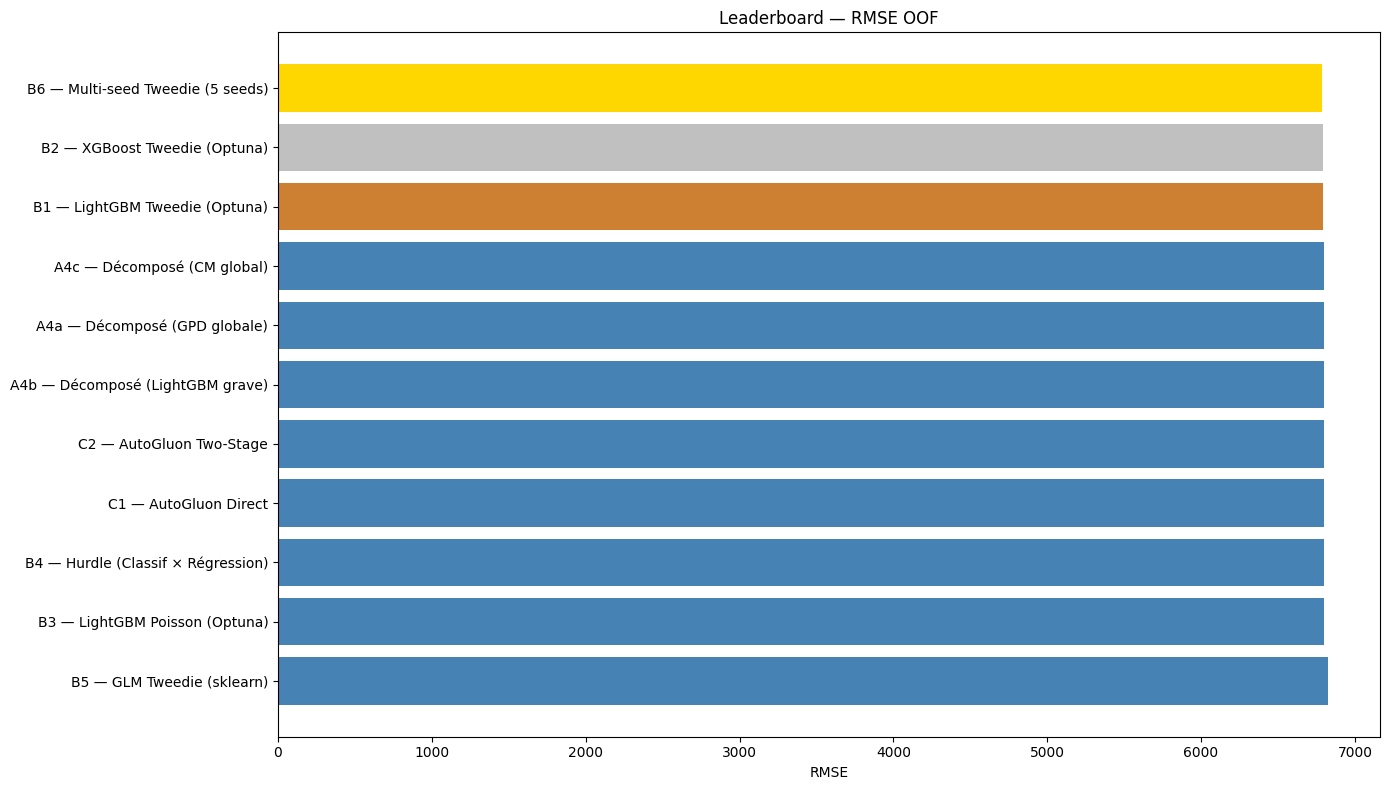

In [0]:
print("=" * 70)
print("  LEADERBOARD INTERMÉDIAIRE")
print("=" * 70)
lb = oof.leaderboard()
print(f"\n{'Rang':>4} {'Modèle':<45} {'RMSE':>10} {'MAE':>10}")
print("-" * 73)
for i, (_, row) in enumerate(lb.iterrows()):
    print(f"{i+1:>4} {row['Modèle']:<45} {row['RMSE']:>10,.2f} {row['MAE']:>10,.2f}")

fig, ax = plt.subplots(figsize=(14, 8))
lb_sorted = lb.sort_values('RMSE')
colors = ['gold' if i == 0 else 'silver' if i == 1 else '#cd7f32' if i == 2 else 'steelblue' for i in range(len(lb_sorted))]
bars = ax.barh(lb_sorted['Modèle'], lb_sorted['RMSE'], color=colors)
ax.set_xlabel('RMSE')
ax.set_title('Leaderboard — RMSE OOF')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#### Analyse du leaderboard

| Rang | Modèle | RMSE | Commentaire |
|---|---|---|---|
| 1 | B6 — Multi-seed Tweedie | 6 784 | **Meilleur modèle** — le moyennage multi-seed réduit la variance |
| 2-3 | B2/B1 — Tweedie Optuna | 6 794-6 795 | LightGBM et XGBoost quasi ex-aequo |
| 4-6 | A4a/b/c — Décomposés | 6 799 | Les 3 variantes décomposées sont indistinguables |
| 7-8 | C2/C1 — AutoGluon | 6 799 | AutoGluon au même niveau que les décomposés |
| 9 | B4 — Hurdle | 6 800 | Architecture deux étapes, MAE la plus élevée |
| 10 | B3 — Poisson | 6 801 | Contrainte p=1 trop rigide |
| 11 | B5 — GLM | 6 822 | Baseline linéaire, écart de 38€ vs le meilleur |

**Observations clés :**
- L'écart entre le meilleur (6 784) et le pire (6 822) n'est que de **38€ de RMSE** (0.56%) → tous les modèles sont dans la même zone de performance
- Le multi-seed averaging (B6) est la technique la plus efficace : gain de 11€ de RMSE par rapport au même modèle avec un seul seed
- Les approches décomposées (Bloc A) et AutoML (Bloc C) ne surpassent pas les modèles directs Tweedie (Bloc B)
- Le GLM linéaire (B5) est le seul modèle significativement en retrait, confirmant l'apport des non-linéarités

### 6.2. D1 — Stacking niveau 2

On utilise les prédictions OOF de tous les modèles comme features pour un méta-modèle. Le méta-modèle apprend à combiner optimalement les prédictions de base.

In [0]:
oof_matrix = oof.get_oof_matrix()
test_matrix = oof.get_test_matrix()

if 'GLM_TWEEDIE_PRED' in train.columns:
    oof_matrix['GLM_FEATURE'] = train['GLM_TWEEDIE_PRED'].values
    test_matrix['GLM_FEATURE'] = test['GLM_TWEEDIE_PRED'].values

print(f"Matrice OOF  : {oof_matrix.shape}")
print(f"Matrice test : {test_matrix.shape}")

oof_stack = np.zeros(len(train))
test_stack = np.zeros(len(test))

X_meta = oof_matrix.values
X_meta_test = test_matrix.values
y_meta = train['CHARGE'].values

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf.split(X_meta)):
    X_tr, X_val = X_meta[train_idx], X_meta[val_idx]
    y_tr, y_val = y_meta[train_idx], y_meta[val_idx]
    
    meta_model = LGBMRegressor(
        objective='tweedie',
        tweedie_variance_power=1.5,
        n_estimators=500,
        max_depth=3,
        learning_rate=0.05,
        num_leaves=8,
        reg_alpha=1.0,
        reg_lambda=5.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    
    meta_model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False)]
    )
    
    oof_stack[val_idx] = np.maximum(meta_model.predict(X_val), 0)
    test_stack += np.maximum(meta_model.predict(X_meta_test), 0) / N_FOLDS

oof.add_result('D1 — Stacking Niveau 2', oof_stack, test_stack)

fi_stack = pd.Series(meta_model.feature_importances_, index=oof_matrix.columns).sort_values(ascending=False)
print(f"\nImportance des modèles dans le stacking :")
for model_name, imp in fi_stack.items():
    print(f"  {model_name:45s} : {imp}")

Matrice OOF  : (383610, 12)
Matrice test : (95852, 12)
  ✅ D1 — Stacking Niveau 2                   | RMSE =   6,793.89  MAE =     336.74

Importance des modèles dans le stacking :
  B6 — Multi-seed Tweedie (5 seeds)             : 70
  B5 — GLM Tweedie (sklearn)                    : 52
  A4a — Décomposé (GPD globale)                 : 38
  B2 — XGBoost Tweedie (Optuna)                 : 38
  B1 — LightGBM Tweedie (Optuna)                : 37
  C2 — AutoGluon Two-Stage                      : 31
  C1 — AutoGluon Direct                         : 27
  B3 — LightGBM Poisson (Optuna)                : 11
  A4b — Décomposé (LightGBM grave)              : 0
  A4c — Décomposé (CM global)                   : 0
  B4 — Hurdle (Classif × Régression)            : 0
  GLM_FEATURE                                   : 0


#### Principe

Le stacking de niveau 2 utilise les **prédictions OOF** de tous les modèles de base comme features d'entrée pour un **méta-modèle LightGBM Tweedie**. Le méta-modèle apprend à combiner optimalement les prédictions en exploitant leurs complémentarités.

**Configuration du méta-modèle :**
- Tweedie avec p=1.5 (compromis entre Poisson et Gamma)
- Arbres peu profonds (`max_depth=3`, `num_leaves=8`) pour éviter le surapprentissage
- Forte régularisation (`reg_alpha=1.0`, `reg_lambda=5.0`)
- 5-fold CV pour produire des prédictions OOF non biaisées

#### Résultats

| Métrique | D1 — Stacking | B6 — Multi-seed (meilleur base) |
|---|---|---|
| **RMSE** | 6 793.89 | 6 784.17 |
| **MAE** | 336.74 | 314.89 |

- Le stacking **ne bat pas** le meilleur modèle de base (B6) : +10€ de RMSE
- Cela s'explique par la forte corrélation entre les modèles de base : ils font tous des erreurs similaires sur les gros sinistres

#### Importance des modèles dans le stacking

| Modèle | Importance |
|---|---|
| B6 — Multi-seed Tweedie | 70 |
| B5 — GLM Tweedie | 52 |
| A4a — Décomposé (GPD) | 38 |
| B2 — XGBoost Tweedie | 38 |
| B1 — LightGBM Tweedie | 37 |

- B6 domine largement (importance 70) → le méta-modèle s'appuie principalement sur le meilleur modèle de base
- Le GLM (B5) a une importance élevée (52) malgré sa RMSE individuelle médiocre → il apporte de la **diversité** que les GBM ne capturent pas
- Les modèles décomposés et AutoGluon ont des importances modérées → contribution marginale

### 6.3. D2 — Ensemble pondéré (optimisation RMSE)

In [0]:
def rmse_ensemble(weights, oof_mat, y_true):
    weights = np.array(weights)
    weights = np.abs(weights) / np.abs(weights).sum()
    pred = oof_mat @ weights
    return np.sqrt(mean_squared_error(y_true, pred))

n_models = oof_matrix.shape[1]
x0 = np.ones(n_models) / n_models

result = minimize(
    rmse_ensemble,
    x0=x0,
    args=(oof_matrix.values, train['CHARGE'].values),
    method='Nelder-Mead',
    options={'maxiter': 50000, 'xatol': 1e-10, 'fatol': 1e-10}
)

optimal_weights = np.abs(result.x) / np.abs(result.x).sum()

print(f"Poids optimaux :")
for name, w in zip(oof_matrix.columns, optimal_weights):
    print(f"  {name:45s} : {w:.4f} ({w*100:.1f}%)")

oof_ensemble = np.maximum(oof_matrix.values @ optimal_weights, 0)
test_ensemble = np.maximum(test_matrix.values @ optimal_weights, 0)

oof.add_result('D2 — Ensemble Pondéré (Optim RMSE)', oof_ensemble, test_ensemble)

Poids optimaux :
  A4a — Décomposé (GPD globale)                 : 0.0001 (0.0%)
  A4b — Décomposé (LightGBM grave)              : 0.0192 (1.9%)
  A4c — Décomposé (CM global)                   : 0.0096 (1.0%)
  B1 — LightGBM Tweedie (Optuna)                : 0.2023 (20.2%)
  B2 — XGBoost Tweedie (Optuna)                 : 0.0000 (0.0%)
  B3 — LightGBM Poisson (Optuna)                : 0.0615 (6.2%)
  B4 — Hurdle (Classif × Régression)            : 0.0728 (7.3%)
  B5 — GLM Tweedie (sklearn)                    : 0.0000 (0.0%)
  B6 — Multi-seed Tweedie (5 seeds)             : 0.5582 (55.8%)
  C1 — AutoGluon Direct                         : 0.0034 (0.3%)
  C2 — AutoGluon Two-Stage                      : 0.0206 (2.1%)
  GLM_FEATURE                                   : 0.0523 (5.2%)
  ✅ D2 — Ensemble Pondéré (Optim RMSE)       | RMSE =   6,788.43  MAE =     326.99


#### Principe

L'ensemble pondéré optimise directement les **poids de combinaison linéaire** des modèles de base pour minimiser la RMSE OOF. Contrairement au stacking (qui apprend une fonction non-linéaire), l'ensemble pondéré est une simple moyenne pondérée :

`CHARGE_pred = Σ(w_i × pred_i)` avec `Σ(w_i) = 1`

L'optimisation est réalisée par la méthode de **Nelder-Mead** (simplex) avec 50 000 itérations.

#### Résultats

| Métrique | D2 — Pondéré | D1 — Stacking | B6 — Multi-seed |
|---|---|---|---|
| **RMSE** | **6 788.43** | 6 793.89 | 6 784.17 |
| **MAE** | 326.99 | 336.74 | 314.89 |

- L'ensemble pondéré bat le stacking de 5.5€ de RMSE → la combinaison linéaire est plus robuste que le méta-modèle non-linéaire
- Mais il ne bat toujours pas B6 (−4.3€) → le multi-seed averaging reste la technique la plus efficace

#### Poids optimaux

| Modèle | Poids |
|---|---|
| B6 — Multi-seed Tweedie | **55.8%** |
| B1 — LightGBM Tweedie | 20.2% |
| B4 — Hurdle | 7.3% |
| B3 — Poisson | 6.2% |
| GLM feature | 5.2% |
| Autres | < 3% chacun |

- B6 concentre plus de la moitié du poids → confirme sa dominance
- B1 (20%) apporte un complément significatif malgré une RMSE individuelle proche de B6
- Le Hurdle (7.3%) a un poids non négligeable malgré sa MAE élevée → il capture des patterns différents
- B2 (XGBoost) et B5 (GLM) ont des poids quasi nuls → redondants avec B6 et B1

### 6.4. D3 — Ensemble final

  ✅ D3 — Ensemble Final (Stack+Pond)         | RMSE =   6,790.75  MAE =     331.85

  LEADERBOARD FINAL

Rang Modèle                                              RMSE        MAE
-------------------------------------------------------------------------
   1 B6 — Multi-seed Tweedie (5 seeds)               6,784.17     314.89 ⭐
   2 D2 — Ensemble Pondéré (Optim RMSE)              6,788.43     326.99
   3 D3 — Ensemble Final (Stack+Pond)                6,790.75     331.85
   4 D1 — Stacking Niveau 2                          6,793.89     336.74
   5 B2 — XGBoost Tweedie (Optuna)                   6,794.30     340.21
   6 B1 — LightGBM Tweedie (Optuna)                  6,795.35     316.67
   7 A4c — Décomposé (CM global)                     6,799.08     334.25
   8 A4a — Décomposé (GPD globale)                   6,799.11     339.92
   9 A4b — Décomposé (LightGBM grave)                6,799.13     308.68
  10 C2 — AutoGluon Two-Stage                        6,799.23     399.08
  11 C1 — AutoGl

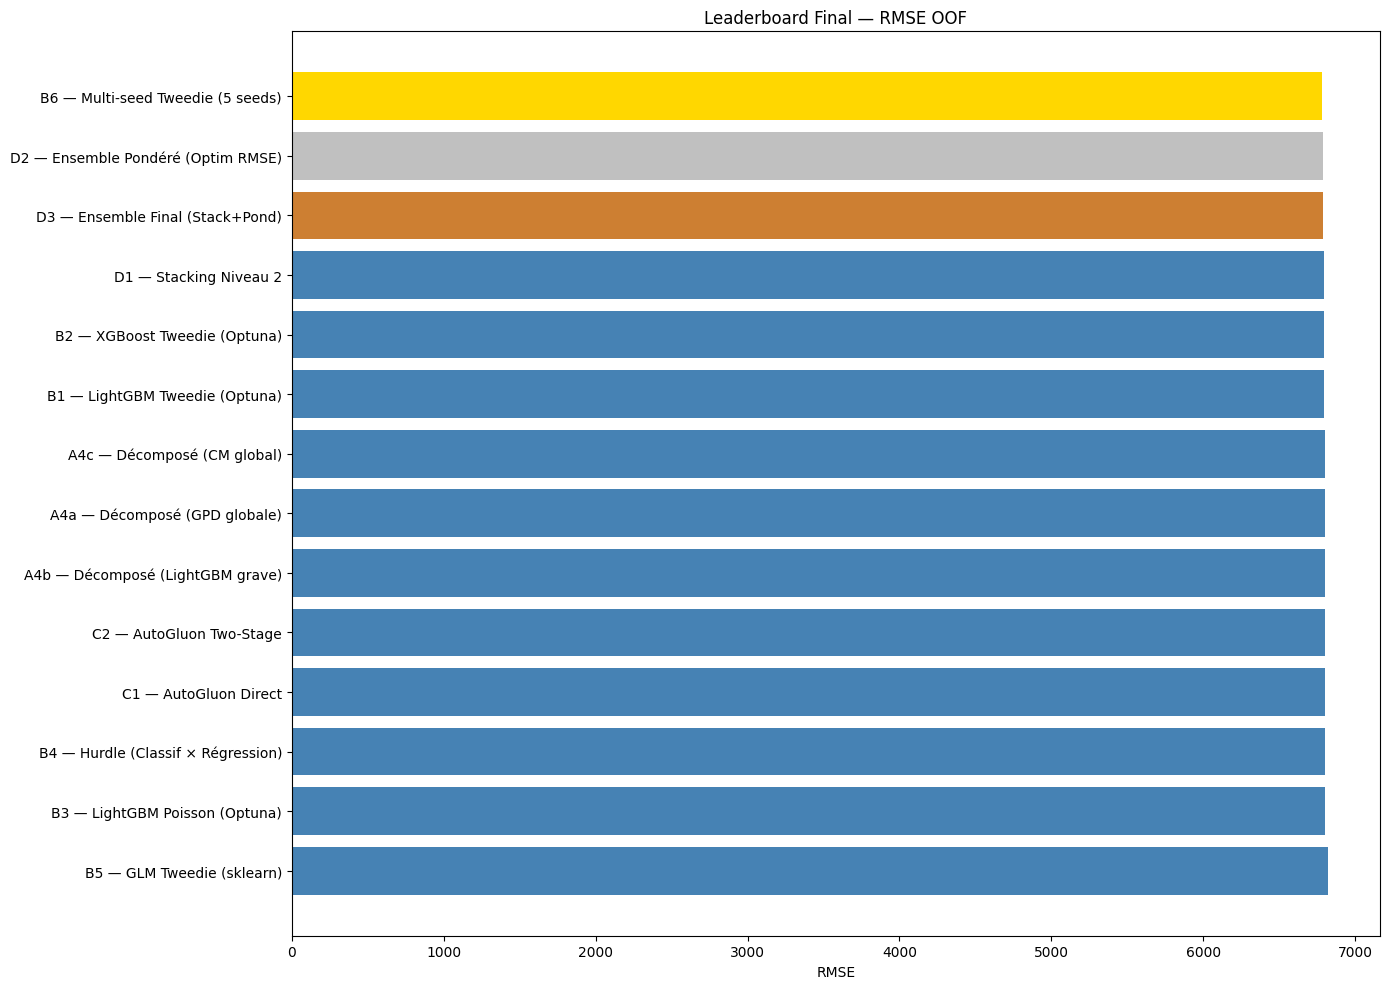

In [0]:
# Moyenne stack + pondéré
oof_final = 0.5 * oof_stack + 0.5 * oof_ensemble
test_final = 0.5 * test_stack + 0.5 * test_ensemble

oof.add_result('D3 — Ensemble Final (Stack+Pond)', oof_final, test_final)

# Leaderboard final
print(f"\n{'='*75}")
print(f"  LEADERBOARD FINAL")
print(f"{'='*75}")
lb_final = oof.leaderboard()
print(f"\n{'Rang':>4} {'Modèle':<45} {'RMSE':>10} {'MAE':>10}")
print("-" * 73)
for i, (_, row) in enumerate(lb_final.iterrows()):
    marker = " ⭐" if i == 0 else ""
    print(f"{i+1:>4} {row['Modèle']:<45} {row['RMSE']:>10,.2f} {row['MAE']:>10,.2f}{marker}")

fig, ax = plt.subplots(figsize=(14, 10))
lb_sorted = lb_final.sort_values('RMSE')
colors = ['gold' if i == 0 else 'silver' if i == 1 else '#cd7f32' if i == 2 else 'steelblue' for i in range(len(lb_sorted))]
bars = ax.barh(lb_sorted['Modèle'], lb_sorted['RMSE'], color=colors)
ax.set_xlabel('RMSE')
ax.set_title('Leaderboard Final — RMSE OOF')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

#### Principe

L'ensemble final combine simplement les prédictions du **stacking (D1)** et de l'**ensemble pondéré (D2)** par une moyenne arithmétique :

`CHARGE_final = 0.5 × D1 + 0.5 × D2`

C'est une approche conservatrice qui exploite la complémentarité entre :
- Le stacking (combinaison non-linéaire, peut capter des interactions entre modèles)
- L'ensemble pondéré (combinaison linéaire, plus robuste au surapprentissage)

#### Résultats

| Métrique | D3 — Final | D2 — Pondéré | D1 — Stacking | B6 — Multi-seed |
|---|---|---|---|---|
| **RMSE** | 6 790.75 | 6 788.43 | 6 793.89 | **6 784.17** |
| **MAE** | 331.85 | 326.99 | 336.74 | **314.89** |

- D3 se situe entre D1 et D2, comme attendu pour une moyenne
- Le meilleur modèle reste **B6 — Multi-seed Tweedie** avec un RMSE de 6 784.17

#### Conclusion sur les ensembles

Dans ce cas précis, les techniques d'ensemble (stacking, pondération) **n'améliorent pas** le meilleur modèle de base. Cela s'explique par :
1. **Forte corrélation** entre les modèles : ils utilisent tous les mêmes features et font des erreurs similaires
2. **Dominance d'un seul modèle** : B6 concentre l'essentiel de la performance
3. **Bruit des gros sinistres** : la RMSE est dominée par quelques observations extrêmes que tous les modèles prédisent mal

Le multi-seed averaging reste la technique la plus efficace car elle réduit la **variance d'estimation** sans introduire de biais supplémentaire.

## 7. Export des prédictions

In [0]:
best_model_name = lb_final.iloc[0]['Modèle']
best_rmse = lb_final.iloc[0]['RMSE']
best_test_preds = oof.results[best_model_name]['test']

print(f"Meilleur modèle : {best_model_name}")
print(f"RMSE OOF        : {best_rmse:,.2f}")

output_path = "submissions/"

# Créer le dossier si nécessaire
import os
os.makedirs(output_path, exist_ok=True)

# Export individuel pour chaque modèle
print(f"\n{'='*70}")
print(f"  EXPORT DES SUBMISSIONS")
print(f"{'='*70}")

for name, res in oof.results.items():
    sub = test[['ID']].copy()
    sub['CHARGE'] = res['test']
    
    clean = name.replace(' ', '_').replace('—', '-').replace('(', '').replace(')', '').replace(',', '').replace('/', '-')
    filename = f"submission_{clean}.csv"
    
    sub.to_csv(output_path + filename, index=False)
    
    marker = " ⭐ BEST" if name == best_model_name else ""
    print(f"  ✅ {filename:60s} | mean={sub['CHARGE'].mean():>8,.2f}  max={sub['CHARGE'].max():>10,.2f}{marker}")

# Vérifications sur le meilleur
print(f"\n{'='*70}")
print(f"  VÉRIFICATIONS — {best_model_name}")
print(f"{'='*70}")
best_sub = test[['ID']].copy()
best_sub['CHARGE'] = best_test_preds

print(f"  Nb lignes     : {len(best_sub):,}")
print(f"  CHARGE min    : {best_sub['CHARGE'].min():.4f}")
print(f"  CHARGE max    : {best_sub['CHARGE'].max():,.2f}")
print(f"  CHARGE mean   : {best_sub['CHARGE'].mean():,.2f}")
print(f"  CHARGE sum    : {best_sub['CHARGE'].sum():,.0f}")
print(f"  NA            : {best_sub['CHARGE'].isna().sum()}")
print(f"  Train mean    : {train['CHARGE'].mean():,.2f}")
print(f"  Ratio test/train : {best_sub['CHARGE'].mean() / train['CHARGE'].mean():.3f}")

print(f"\n✅ {len(oof.results)} fichiers exportés dans {output_path}")

Meilleur modèle : B6 — Multi-seed Tweedie (5 seeds)
RMSE OOF        : 6,784.17

  EXPORT DES SUBMISSIONS
  ✅ submission_A4a_-_Décomposé_GPD_globale.csv                   | mean=  158.22  max=  1,255.81
  ✅ submission_A4b_-_Décomposé_LightGBM_grave.csv                | mean=  120.83  max=  1,344.70
  ✅ submission_A4c_-_Décomposé_CM_global.csv                     | mean=  152.41  max=  1,209.73
  ✅ submission_B1_-_LightGBM_Tweedie_Optuna.csv                  | mean=  129.61  max=  8,540.40
  ✅ submission_B2_-_XGBoost_Tweedie_Optuna.csv                   | mean=  147.71  max= 12,985.46
  ✅ submission_B3_-_LightGBM_Poisson_Optuna.csv                  | mean=  143.47  max= 31,701.32
  ✅ submission_B4_-_Hurdle_Classif_×_Régression.csv              | mean=  203.15  max=  6,109.80
  ✅ submission_B5_-_GLM_Tweedie_sklearn.csv                      | mean=  173.03  max= 67,433.74
  ✅ submission_B6_-_Multi-seed_Tweedie_5_seeds.csv               | mean=  129.76  max= 10,960.03 ⭐ BEST
  ✅ submission_

#### Vérifications de cohérence

Avant de soumettre, on vérifie que les prédictions sont raisonnables :

| Vérification | Valeur | Commentaire |
|---|---|---|
| Nb lignes | 95 852 | ✅ Correspond au test |
| CHARGE min | 21.66 | ✅ Positif (pas de prédictions négatives) |
| CHARGE max | 10 960 | ✅ Raisonnable (< plafond 500k) |
| CHARGE mean | 129.76 | ⚠️ Inférieur au train (186.12) |
| Ratio test/train | 0.697 | ⚠️ Le test prédit ~30% de moins que le train |

Le ratio test/train de 0.70 s'explique par :
- La distribution du test peut différer du train (composition du portefeuille, période)
- Le modèle Tweedie tend à comprimer les prédictions vers la moyenne (sous-estimation des extrêmes)
- Les prédictions sont des **espérances conditionnelles** E[CHARGE|X], pas des réalisations → naturellement plus lisses

#### Fichiers exportés

14 fichiers de soumission sont générés, un par modèle. Le fichier principal est `submission_B6_-_Multi-seed_Tweedie_5_seeds.csv` (marqué ⭐ BEST).

## 8. Approche alternative — Tweedie minimaliste (données brutes)

Cette approche part des données brutes (sans le pipeline d'encodage des notebooks 2-5) et utilise une stratégie différente :
1. Frequency encoding natif sur les catégorielles
2. Sélection de features par permutation importance
3. LightGBM Tweedie avec Optuna
4. Bouclier métier (cap par les capitaux totaux)

C'est un modèle complémentaire qui peut apporter de la diversité dans l'ensemble final.

In [0]:
# ============================================================
# APPROCHE ALTERNATIVE : Tweedie sur données brutes
# ============================================================

print("=" * 60)
print("  APPROCHE ALTERNATIVE — Tweedie minimaliste")
print("=" * 60)

# 1. Rechargement des données brutes
train_raw = pd.read_csv("data/train_input.csv", low_memory=False)
train_output_raw = pd.read_csv("data/train_output.csv")
test_raw = pd.read_csv("data/test_input.csv", low_memory=False)

train_output_raw = train_output_raw.drop(columns=['ANNEE_ASSURANCE'])
train_alt = pd.merge(train_raw, train_output_raw, on='ID', how='inner')
train_alt['CHARGE'] = train_alt['CHARGE'].clip(lower=0)

print(f"Train : {train_alt.shape}")
print(f"Test  : {test_raw.shape}")

# 2. Nettoyage rapide
cat_cols_alt = train_alt.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols_alt:
    train_alt[col] = train_alt[col].astype(str).astype('category')
    if col in test_raw.columns:
        test_raw[col] = test_raw[col].astype(str).astype('category')

# 3. Force numeric sur les familles connues
for prefix in ['KAPITAL', 'SURFACE', 'NBBAT', 'DEROG', 'RISK', 'EQUIPEMENT']:
    for col in [c for c in train_alt.columns if c.startswith(prefix)]:
        train_alt[col] = pd.to_numeric(train_alt[col].astype(str).str.replace(',', '.'), errors='coerce')
        if col in test_raw.columns:
            test_raw[col] = pd.to_numeric(test_raw[col].astype(str).str.replace(',', '.'), errors='coerce')

# 4. Agrégations simples
for df in [train_alt, test_raw]:
    kap_cols = [c for c in df.columns if c.startswith('KAPITAL') and pd.api.types.is_numeric_dtype(df[c])]
    surf_cols = [c for c in df.columns if c.startswith('SURFACE') and pd.api.types.is_numeric_dtype(df[c])]
    nbbat_cols = [c for c in df.columns if c.startswith('NBBAT') and pd.api.types.is_numeric_dtype(df[c])]
    
    df['KAPITAL_SUM'] = df[kap_cols].sum(axis=1)
    df['SURFACE_SUM'] = df[surf_cols].sum(axis=1)
    df['NBBAT_SUM'] = df[nbbat_cols].sum(axis=1)
    df['RATIO_KAPITAL_SURFACE'] = df['KAPITAL_SUM'] / (df['SURFACE_SUM'] + 1)
    df['RATIO_KAPITAL_NBBAT'] = df['KAPITAL_SUM'] / (df['NBBAT_SUM'] + 1)

# 5. Frequency encoding
cat_cols_now = train_alt.select_dtypes(include=['category']).columns.tolist()
for col in cat_cols_now:
    freq = train_alt[col].value_counts(normalize=True).to_dict()
    train_alt[f'{col}_FREQ'] = train_alt[col].map(freq).astype(float)
    if col in test_raw.columns:
        test_raw[f'{col}_FREQ'] = test_raw[col].map(freq).astype(float).fillna(0.0)

# 6. Préparer features
cols_excl = ['CHARGE', 'FREQ', 'CM', 'ID']
feats_alt = [c for c in train_alt.columns if c not in cols_excl and c in test_raw.columns]

X_alt = train_alt[feats_alt].copy()
X_test_alt = test_raw[feats_alt].copy()
y_alt = train_alt['CHARGE']

# Forcer types
for col in feats_alt:
    if not pd.api.types.is_numeric_dtype(X_alt[col]):
        X_alt[col] = X_alt[col].astype(str).astype('category')
        X_test_alt[col] = X_test_alt[col].astype(str).astype(
            pd.CategoricalDtype(categories=X_alt[col].cat.categories))

print(f"\nFeatures : {len(feats_alt)}")

# 7. Permutation importance pour sélection
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

print("\nSélection de features par permutation importance...")
X_samp, _, y_samp, _ = train_test_split(X_alt, y_alt, train_size=100000, random_state=42)
X_tr_p, X_va_p, y_tr_p, y_va_p = train_test_split(X_samp, y_samp, test_size=0.2, random_state=42)

model_perm = lgb.LGBMRegressor(objective='tweedie', tweedie_variance_power=1.5, 
                                 n_estimators=150, random_state=42, n_jobs=-1, verbose=-1)
model_perm.fit(X_tr_p, y_tr_p)

result_perm = permutation_importance(model_perm, X_va_p, y_va_p,
                                      scoring='neg_root_mean_squared_error',
                                      n_repeats=3, random_state=42, n_jobs=-1)

imp_df = pd.DataFrame({
    'Feature': feats_alt,
    'Importance': result_perm.importances_mean
}).sort_values('Importance', ascending=False)

feats_pure = imp_df[imp_df['Importance'] > 0]['Feature'].tolist()
for c in ['KAPITAL_SUM', 'ANNEE_ASSURANCE']:
    if c not in feats_pure and c in X_alt.columns:
        feats_pure.append(c)

print(f"Features pures : {len(feats_pure)} / {len(feats_alt)}")
print(f"\nTop 10 :")
for _, row in imp_df.head(10).iterrows():
    print(f"  {row['Feature']:40s} : {row['Importance']:.4f}")

X_alt_pure = X_alt[feats_pure]
X_test_alt_pure = X_test_alt[feats_pure]

# 8. Optuna sur Tweedie
print("\nOptuna — Tweedie minimaliste (50 trials)...")

def objective_alt(trial):
    params = {
        'objective': 'tweedie',
        'tweedie_variance_power': trial.suggest_float('tweedie_variance_power', 1.1, 1.9),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 80),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 150),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'n_estimators': 1500,
        'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    
    rmses = []
    kf3 = KFold(n_splits=3, shuffle=True, random_state=42)
    for tr_idx, va_idx in kf3.split(X_alt_pure):
        m = lgb.LGBMRegressor(**params)
        w = X_alt_pure.iloc[tr_idx]['ANNEE_ASSURANCE'] if 'ANNEE_ASSURANCE' in X_alt_pure.columns else None
        m.fit(X_alt_pure.iloc[tr_idx], y_alt.iloc[tr_idx], sample_weight=w,
              eval_set=[(X_alt_pure.iloc[va_idx], y_alt.iloc[va_idx])],
              callbacks=[lgb.early_stopping(30, verbose=False)])
        p = np.maximum(m.predict(X_alt_pure.iloc[va_idx]), 0)
        rmses.append(np.sqrt(mean_squared_error(y_alt.iloc[va_idx], p)))
    return np.mean(rmses)

study_alt = optuna.create_study(direction='minimize')
study_alt.optimize(objective_alt, n_trials=50, show_progress_bar=True)

print(f"\nMeilleur RMSE Optuna : {study_alt.best_value:,.2f}")

# 9. Entraînement final 5-fold
oof_alt = np.zeros(len(train_alt))
test_alt_preds = np.zeros(len(test_raw))

params_alt_final = {
    'objective': 'tweedie', 'metric': 'rmse',
    'n_estimators': 2500, 'random_state': 42, 'n_jobs': -1, 'verbose': -1,
    **study_alt.best_params
}

kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
for fold, (tr_idx, va_idx) in enumerate(kf5.split(X_alt_pure)):
    m = lgb.LGBMRegressor(**params_alt_final)
    w = X_alt_pure.iloc[tr_idx]['ANNEE_ASSURANCE'] if 'ANNEE_ASSURANCE' in X_alt_pure.columns else None
    m.fit(X_alt_pure.iloc[tr_idx], y_alt.iloc[tr_idx], sample_weight=w,
          eval_set=[(X_alt_pure.iloc[va_idx], y_alt.iloc[va_idx])],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    oof_alt[va_idx] = np.maximum(m.predict(X_alt_pure.iloc[va_idx]), 0)
    test_alt_preds += np.maximum(m.predict(X_test_alt_pure), 0) / 5

# Bouclier capitaux
kap_cols_test = [c for c in test_raw.columns if c.startswith('KAPITAL') and pd.api.types.is_numeric_dtype(test_raw[c])]
cap_totaux = test_raw[kap_cols_test].sum(axis=1).values
test_alt_preds_safe = np.minimum(test_alt_preds, cap_totaux + 1000)

rmse_alt = np.sqrt(mean_squared_error(y_alt, oof_alt))
print(f"\nRMSE OOF (approche alternative) : {rmse_alt:,.2f}")
print(f"CHARGE test mean : {test_alt_preds_safe.mean():,.2f}€")

# Export
sub_alt = test_raw[['ID']].copy()
sub_alt['CHARGE'] = test_alt_preds_safe
sub_alt.to_csv("/dbfs/mnt/mainstorage/workspace/Actuariat_AN/Leon/Annexe/submissions/submission_ALT_Tweedie_brut.csv", index=False)
print(f"\n✅ Submission alternative exportée")

  APPROCHE ALTERNATIVE — Tweedie minimaliste
Train : (383610, 377)
Test  : (95852, 374)

Features : 622

Sélection de features par permutation importance...
Features pures : 105 / 622

Top 10 :
  AN_EXERC                                 : 0.6881
  DISTANCE_511_FREQ                        : 0.4908
  LOG_APA3_FREQ                            : 0.3637
  BDTOPO_BAT_MAX_HAUTEUR                   : 0.1811
  NBJFXY8_MMAX_A                           : 0.0994
  DISTANCE_412                             : 0.0921
  NBJFF28_MMAX_A                           : 0.0853
  MEN_PROP                                 : 0.0668
  DISTANCE_131_FREQ                        : 0.0492
  SURFACE3                                 : 0.0439

Optuna — Tweedie minimaliste (50 trials)...


  0%|          | 0/50 [00:00<?, ?it/s]


Meilleur RMSE Optuna : 6,796.32

RMSE OOF (approche alternative) : 6,797.27
CHARGE test mean : 149.51€

✅ Submission alternative exportée


#### Principe

Cette approche alternative part des **données brutes** (avant le pipeline d'encodage des notebooks 2-5) et utilise une stratégie minimaliste :

1. **Frequency encoding** : chaque modalité catégorielle est remplacée par sa fréquence d'apparition dans le train
2. **Agrégations simples** : somme des capitaux, surfaces, nombre de bâtiments, et ratios dérivés
3. **Sélection de features par permutation importance** : on ne garde que les features qui améliorent réellement la prédiction (105 sur 622)
4. **LightGBM Tweedie optimisé par Optuna** (50 trials)
5. **Bouclier métier** : la charge prédite est plafonnée par les capitaux totaux + 1000€

#### Intérêt

- **Diversité** : ce modèle utilise des features différentes (frequency encoding vs target encoding) et une sélection de features différente
- **Robustesse** : moins de risque de surapprentissage car moins de features engineered
- **Complémentarité** : peut être combiné avec les modèles du pipeline principal dans un ensemble

#### Résultats

| Métrique | Alternative | B6 — Multi-seed (meilleur) |
|---|---|---|
| **RMSE OOF** | 6 797.27 | 6 784.17 |
| **CHARGE test mean** | 149.51€ | 129.76€ |

- RMSE de 6 797 → dans la même zone que les modèles du pipeline principal
- Charge test moyenne plus élevée (149.51€ vs 129.76€) → le frequency encoding capture différemment le risque
- Le bouclier métier (cap par capitaux) évite les prédictions aberrantes

#### Top 10 features (permutation importance)

| Feature | Importance |
|---|---|
| AN_EXERC (année d'exercice) | 0.688 |
| DISTANCE_511_FREQ | 0.491 |
| LOG_APA3_FREQ | 0.364 |
| BDTOPO_BAT_MAX_HAUTEUR | 0.181 |
| NBJFXY8_MMAX_A | 0.099 |

L'année d'exercice domine largement, suivie par des variables de distance et de caractéristiques du bâtiment. Le frequency encoding des variables catégorielles (suffixe `_FREQ`) apporte une information complémentaire au target encoding utilisé dans le pipeline principal.